In [1]:
import pandas as pd
import numpy as np
import os

import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import itertools

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import random

In [2]:
#!pip install matplotlib scikit-learn pandas seaborn optuna

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# DATASET PREPARATION

In [4]:
def read_img_labels(xml_path):
    XMLtree = ET.parse(xml_path)
    XMLroot = XMLtree.getroot()
    img_labels = []

    for obj in XMLroot.findall('object'):
        label_name = obj.find('name').text
        bounding_box = obj.find('bndbox')
        
        x_min = int(bounding_box.find('xmin').text)
        y_min = int(bounding_box.find('ymin').text)
        x_max = int(bounding_box.find('xmax').text)
        y_max = int(bounding_box.find('ymax').text)

        img_labels.append((label_name, (x_min, y_min, x_max, y_max)))

    return img_labels

In [5]:
def read_files(files):
    data = []
    dimensions = []

    for file_name in files:
        img_path = os.path.join(data_directory, 'Images', file_name + '.jpg')
        xml_path = os.path.join(data_directory, 'Labels', 'Horizontal Bounding Boxes', file_name + '.xml')

        image = Image.open(img_path)
        image_array = np.array(image)
        if (image_array.shape[2]) != 3:
            continue

        img_labels = read_img_labels(xml_path)

        for label in img_labels:
            width = abs(label[1][0] - label[1][2])
            height = abs(label[1][1] - label[1][3])
            dimensions.append(width)
            dimensions.append(height)

        data.append((image, img_labels))

    return data, dimensions

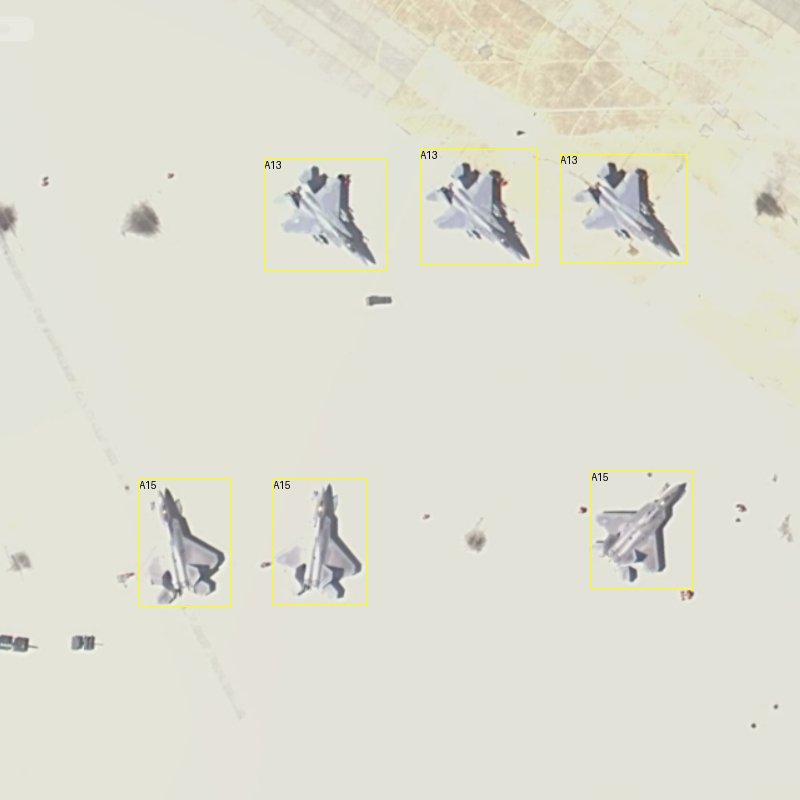

In [6]:
data_directory = './datasets'

with open(os.path.join(data_directory, 'ImageSets/Main/train.txt'), 'r') as f:
    train_fnames = f.read().splitlines()
    
train_data, train_obj_dimensions = read_files(train_fnames)

image = train_data[3][0]
img_to_draw = ImageDraw.Draw(image)
img_objects = train_data[3][1]

for obj in img_objects:
    img_to_draw.text((obj[1][0], obj[1][1]), obj[0], fill='black')
    img_to_draw.rectangle(obj[1], outline='yellow')
image

# PREPROCESSING

In [7]:
def square_img(image):
    image_original_size = image.size
    image_desired_size = (64, 64)

    image_max_dimension = max(image_original_size)

    squares = Image.new("RGB", (image_max_dimension, image_max_dimension))

    x = (image_max_dimension - image_original_size[0]) // 2
    y = (image_max_dimension - image_original_size[1]) // 2
    squares.paste(image, (x, y))

    new_image = squares.resize(image_desired_size)

    return new_image

In [8]:
def object_from_image(image, image_labels):
    objects = []
    labels = []

    for label, bounding_box in image_labels:
        labels.append(label)
        obj_region = image.crop(bounding_box)
        objects.append(obj_region)

    labels = np.array(labels)

    return objects, labels

In [9]:
def data_prep(data):
    X_temporary = []
    y_temporary = []

    for image, image_labels in data:
        objects, labels = object_from_image(image, image_labels)

        squares = []
        for obj in objects:
            square_image = square_img(obj)
            squares.append(square_image)

        X_temporary.append(squares)
        y_temporary.append(labels)

    original_labels = list(itertools.chain(*y_temporary))
    original_labels_np = np.array(original_labels).reshape(-1, 1)

    OHEncoder = OneHotEncoder()
    y = OHEncoder.fit_transform(original_labels_np).toarray()

    n_channels = 4
    X_list = []

    for image in X_temporary:
        for obj in image:
            X_list.append(np.array(obj)/255.0)

    X = np.array(X_list)

    return X, y, original_labels_np

Liczba klas: 20


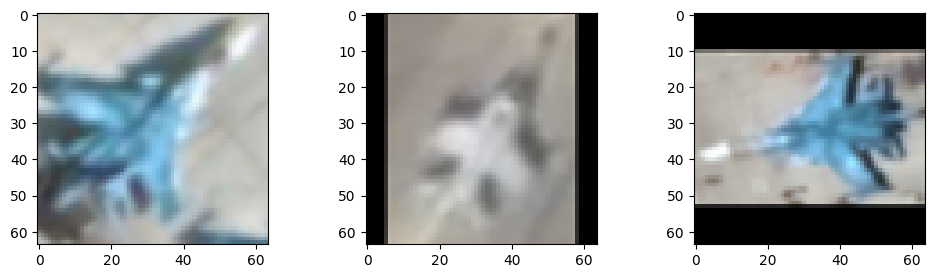

In [10]:
X, y, original_labels = data_prep(train_data)
n_labels = y.shape[1]
print("Liczba klas:", n_labels)

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 3))
ax0.imshow(X[3], cmap='gray')
ax1.imshow(X[43], cmap='gray')
ax2.imshow(X[80], cmap='gray')

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=.7, random_state=10)

print("Dane treningowe:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print("Dane testowe:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Dane treningowe:
X_train: (5468, 64, 64, 3)
y_train: (5468, 20)
Dane testowe:
X_test: (2344, 64, 64, 3)
y_test: (2344, 20)


# MODEL

In [12]:
class CNN(nn.Module):
    def __init__(self, conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential()
        
        in_channels = 3
        for i in range(conv_layers):
            out_channels = filters[i]
            kernel_size = kernel_sizes[i]
            stride = strides[i]
            self.conv_layers.add_module(f'conv{i+1}', nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=1))
            self.conv_layers.add_module(f'relu{i+1}', nn.ReLU())
            self.conv_layers.add_module(f'pool{i+1}', nn.AvgPool2d(kernel_size=2, stride=2))
            in_channels = out_channels
        
        self.flatten = nn.Flatten()
        
        self._to_linear = self.calculate_linear_input(conv_layers, filters, kernel_sizes, strides)
        
        self.fc1 = nn.Linear(self._to_linear, dense_units)
        self.fc2 = nn.Linear(dense_units, 20)
        
        self.dropout = nn.Dropout(dropout_rate)
    
    def calculate_linear_input(self, conv_layers, filters, kernel_sizes, strides):
        size = 64 
        for i in range(conv_layers):
            size = (size - kernel_sizes[i] + 2 * 1) // strides[i] + 1
            size = size // 2
        return filters[-1] * size * size
    
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [13]:
def create_model(conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate):
    model = CNN(conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate)
    return model

In [14]:
# conv_layers_best = best_trial_params['conv_layers']
# filters_best = [best_trial_params[f'filters_{i}'] for i in range(conv_layers_best)]
# kernel_sizes_best = [best_trial_params[f'kernel_size_{i}'] for i in range(conv_layers_best)]
# strides_best = [best_trial_params[f'stride_{i}'] for i in range(conv_layers_best)]
# dense_units_best = best_trial_params['units']
# dropout_rate_best = best_trial_params['dropout']

# best_model_manual_params = create_model(conv_layers_best,
#                                         filters_best,
#                                         kernel_sizes_best,
#                                         strides_best,
#                                         dense_units_best,
#                                         dropout_rate_best).to(device)
# print(best_model_manual_params)


# Teraz możesz ręcznie uruchomić model z własnymi parametrami:
manual_conv_layers = 3
manual_filters = [96, 64, 96]
manual_kernel_sizes = [2, 3, 2]
manual_strides = [1, 1, 1]
manual_dense_units = 64
manual_dropout_rate = 0.5

manual_model = create_model(manual_conv_layers,
                            manual_filters,
                            manual_kernel_sizes,
                            manual_strides,
                            manual_dense_units,
                            manual_dropout_rate).to(device)

print(manual_model)

CNN(
  (conv_layers): Sequential(
    (conv1): Conv2d(3, 96, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (relu1): ReLU()
    (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv2): Conv2d(96, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu2): ReLU()
    (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (conv3): Conv2d(64, 96, kernel_size=(2, 2), stride=(1, 1), padding=(1, 1))
    (relu3): ReLU()
    (pool3): AvgPool2d(kernel_size=2, stride=2, padding=0)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=6144, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=20, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [15]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
y_train_tensor = torch.tensor(y_train.argmax(axis=1), dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_test_tensor = torch.tensor(y_test.argmax(axis=1), dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Optymalizator i funkcja straty
optimizer = optim.Adam(manual_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(18):
    manual_model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = manual_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_train_loss = running_loss / len(train_loader)
    if epoch % 5 == 0:
        print(f'Epoch {epoch}, Training Loss: {avg_train_loss:.4f}')
    
    manual_model.eval()
    correct = 0
    total = 0
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = manual_model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    avg_val_loss = val_loss / len(test_loader)
    accuracy = correct / total
    if epoch % 5 == 0:
        print(f'Epoch {epoch}, Validation Loss: {avg_val_loss:.4f}, Accuracy: {accuracy:.4f}')

manual_model.eval()
predictions = []
with torch.no_grad():
    for X_batch in test_loader:
        X_batch = X_batch[0].to(device)
        outputs = manual_model(X_batch)
        _, predicted = torch.max(outputs.data, 1)
        predictions.extend(predicted.cpu().numpy())

Epoch 0, Training Loss: 2.2584
Epoch 0, Validation Loss: 1.6014, Accuracy: 0.5252
Epoch 5, Training Loss: 0.6345
Epoch 5, Validation Loss: 0.5874, Accuracy: 0.8089
Epoch 10, Training Loss: 0.3452
Epoch 10, Validation Loss: 0.4097, Accuracy: 0.8776
Epoch 15, Training Loss: 0.2125
Epoch 15, Validation Loss: 0.4371, Accuracy: 0.8797


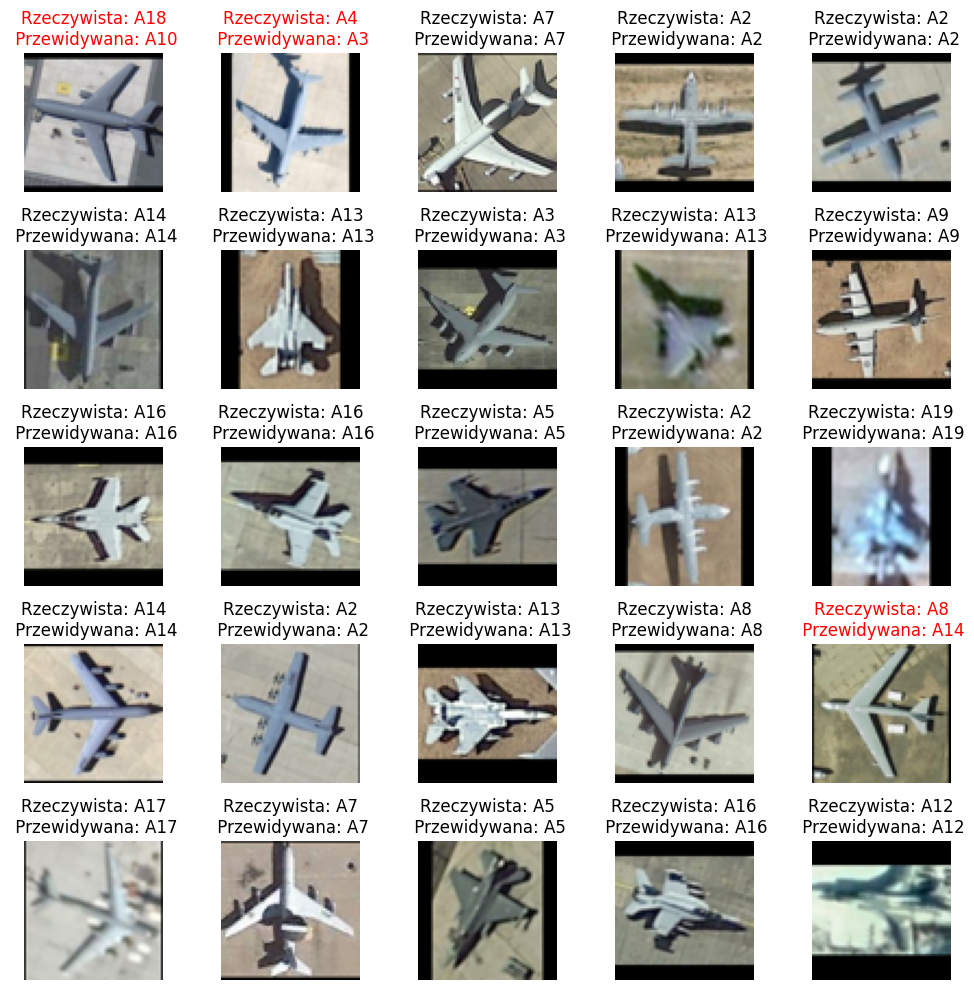

In [53]:
encoder = OneHotEncoder()
encoder.fit(original_labels.reshape(-1, 1))

y_test_np = y_test_tensor.cpu().numpy()
predictions_np = np.array(predictions)
y_orig_true = encoder.categories_[0][y_test_np.astype(int)]
y_orig_pred = encoder.categories_[0][predictions_np.astype(int)]

fig, axs = plt.subplots(5, 5, figsize=(10, 10))
axs = axs.ravel()

random_numbers = [random.randint(0, X_test.shape[0]) for _ in range(25)]

for i, rand in enumerate(random_numbers):
    axs[i].imshow(X_test[rand], cmap='gray')
    axs[i].axis('off')
    if y_orig_true[rand] != y_orig_pred[rand]:
        axs[i].set_title(f"Rzeczywista: {y_orig_true[rand]}\n Przewidywana: {y_orig_pred[rand]}", color='red')
    else:
        axs[i].set_title(f"Rzeczywista: {y_orig_true[rand]}\n Przewidywana: {y_orig_pred[rand]}", color='black')

plt.tight_layout()
plt.savefig('klasyfikacja.png', dpi=300, bbox_inches='tight')
plt.show()

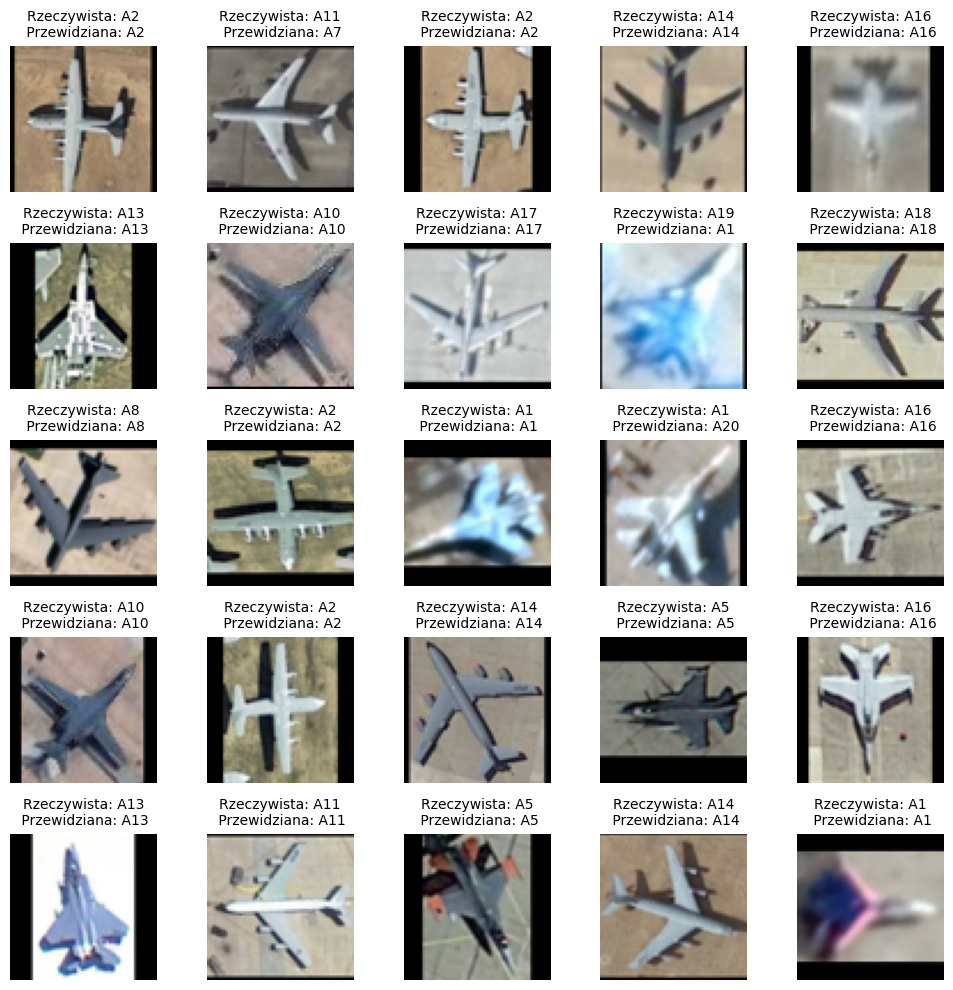

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import OneHotEncoder

# Zakładam, że 'X_test', 'y_test_tensor', 'predictions' już są zdefiniowane

encoder = OneHotEncoder()
encoder.fit(original_labels.reshape(-1, 1))

# Konwersja y_test i predictions do postaci numerycznej
y_test_np = y_test_tensor.cpu().numpy()
predictions_np = np.array(predictions)

# Uzyskanie oryginalnych etykiet
y_orig_true = encoder.categories_[0][y_test_np.astype(int)]
y_orig_pred = encoder.categories_[0][predictions_np.astype(int)]

# Losowanie 25 obrazków
random_numbers = [random.randint(0, X_test.shape[0]) for _ in range(25)]

# Tworzymy wykresy
fig, axs = plt.subplots(5, 5, figsize=(10, 10))
axs = axs.ravel()

# Wybieramy błędnie sklasyfikowane obrazy (3)
incorrect_indexes = [i for i in range(len(y_orig_true)) if y_orig_true[i] != y_orig_pred[i]]
incorrect_samples = random.sample(incorrect_indexes, 3)

# Rysowanie obrazków
for i, rand in enumerate(random_numbers):
    axs[i].imshow(X_test[rand], cmap='gray')
    axs[i].axis('off')
    
    # Jeżeli obrazek jest błędnie sklasyfikowany, zmieniamy kolor tekstu na czerwony
    if rand in incorrect_samples:
        axs[i].set_title(f"Rzeczywista: {y_orig_true[rand]}\n Przewidziana: {y_orig_pred[rand]}", color='red', fontsize=10)
    else:
        axs[i].set_title(f"Rzeczywista: {y_orig_true[rand]}\n Przewidziana: {y_orig_pred[rand]}", color='black', fontsize=10)

# Dopasowanie układu i zapisanie wykresu
plt.tight_layout()
plt.savefig('klasyfikacja.png', dpi=300, bbox_inches='tight')
plt.show()


# METRICS

Accuracy: 0.8951
Precision: 0.8798
Recall: 0.8782
F1 Score: 0.8754
ROC-AUC: 0.9363
Confusion Matrix:


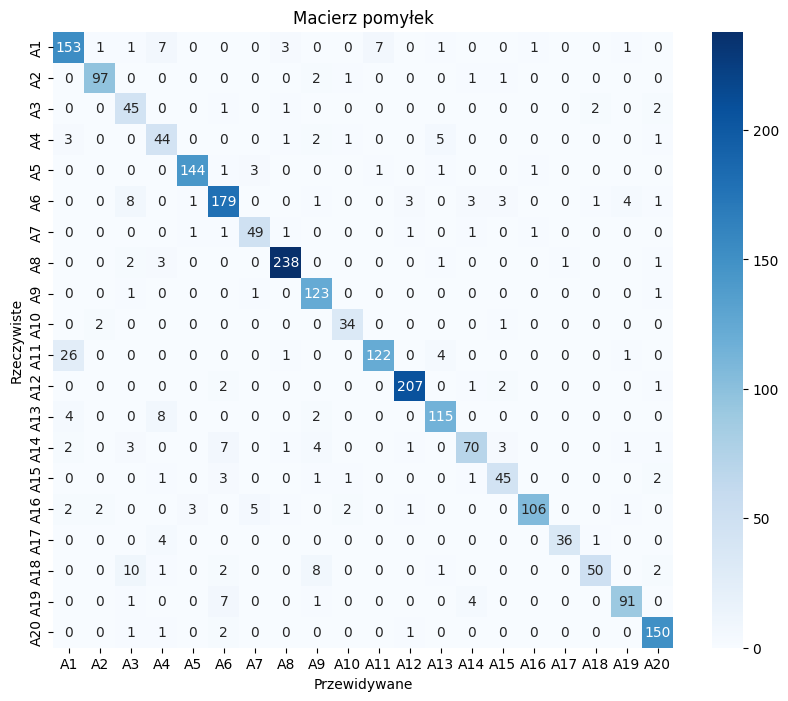

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc

accuracy = accuracy_score(y_test_np, predictions_np)

precision = precision_score(y_test_np, predictions_np, average='macro')

recall = recall_score(y_test_np, predictions_np, average='macro')

f1 = f1_score(y_test_np, predictions_np, average='macro')

conf_matrix = confusion_matrix(y_test_np, predictions_np)

roc_auc = roc_auc_score(y_test_np, torch.nn.functional.one_hot(torch.tensor(predictions_np), num_classes=len(np.unique(y_test_np))), multi_class='ovr')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("Confusion Matrix:")
plt.figure(figsize=(10, 8))
sorted_classes = sorted(encoder.categories_[0], key=lambda x: int(x[1:]))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=sorted_classes, yticklabels=sorted_classes)
plt.xlabel('Przewidywane')
plt.ylabel('Rzeczywiste')
plt.title('Macierz pomyłek')
plt.savefig('macierz_pomylek.png', dpi=300, bbox_inches='tight')
plt.show()


===== RUN 1 / 10 =====

===== RUN 2 / 10 =====

===== RUN 3 / 10 =====

===== RUN 4 / 10 =====

===== RUN 5 / 10 =====

===== RUN 6 / 10 =====

===== RUN 7 / 10 =====

===== RUN 8 / 10 =====

===== RUN 9 / 10 =====

===== RUN 10 / 10 =====

==== Średnie metryki po wszystkich powtórzeniach ====
Accuracy: 0.8907
Precision: 0.8833
Recall: 0.8692
F1 Score: 0.8738
ROC-AUC: 0.9945


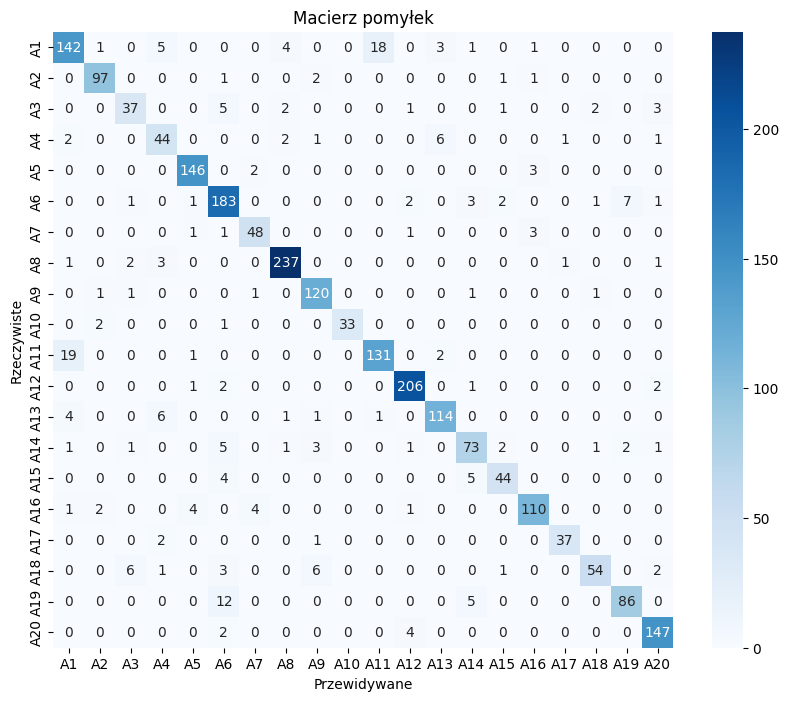

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

# Liczba powtórzeń uczenia
runs = 10

# Liczba epok
epochs = 18

# Listy do zapisu metryk
accuracies, precisions, recalls, f1s, rocs = [], [], [], [], []
conf_matrices = []

for run in range(runs):
    print(f"\n===== RUN {run+1} / {runs} =====")
    
    # Reset modelu i optymalizatora
    model = create_model(manual_conv_layers,
                            manual_filters,
                            manual_kernel_sizes,
                            manual_strides,
                            manual_dense_units,
                            manual_dropout_rate).to(device)  # Upewnij się, że masz klasę manual_model_class()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
    
    # Ewaluacja
    model.eval()
    predictions = []
    true_labels = []
    probas = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            predictions.extend(predicted.cpu().numpy())
            true_labels.extend(y_batch.numpy())
            probas.extend(probs.cpu().numpy())

    # Zamiana na numpy
    y_true = np.array(true_labels)
    y_pred = np.array(predictions)
    y_proba = np.array(probas)

    # Obliczenie metryk
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    roc = roc_auc_score(y_true, y_proba, multi_class='ovr')

    accuracies.append(acc)
    precisions.append(prec)
    recalls.append(rec)
    f1s.append(f1)
    rocs.append(roc)

    conf = confusion_matrix(y_true, y_pred)
    conf_matrices.append(conf)

# Średnie metryki
print("\n==== Średnie metryki po wszystkich powtórzeniach ====")
print(f"Accuracy: {np.mean(accuracies):.4f}")
print(f"Precision: {np.mean(precisions):.4f}")
print(f"Recall: {np.mean(recalls):.4f}")
print(f"F1 Score: {np.mean(f1s):.4f}")
print(f"ROC-AUC: {np.mean(rocs):.4f}")

# Średnia confusion matrix
mean_conf_matrix = np.mean(conf_matrices, axis=0)

# Wyświetlenie confusion matrix
plt.figure(figsize=(10, 8))
sorted_classes = sorted(encoder.categories_[0], key=lambda x: int(x[1:]))  # Zakładam, że masz encoder
sns.heatmap(mean_conf_matrix, annot=True, fmt='.0f', cmap='Blues', xticklabels=sorted_classes, yticklabels=sorted_classes)
plt.xlabel('Przewidywane')
plt.ylabel('Rzeczywiste')
plt.title('Macierz pomyłek'.format(runs))
plt.savefig('macierz_pomylek.png', dpi=300, bbox_inches='tight')
plt.show()


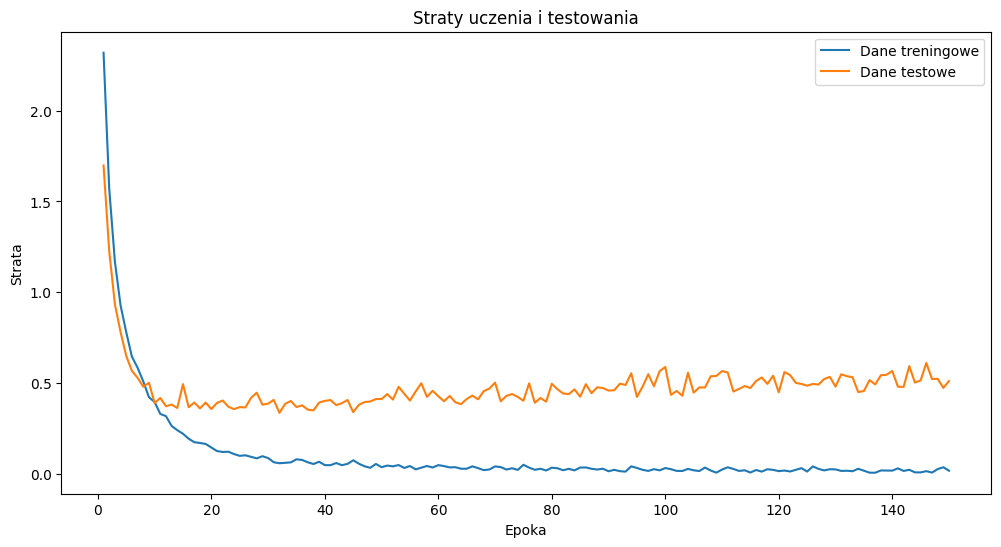

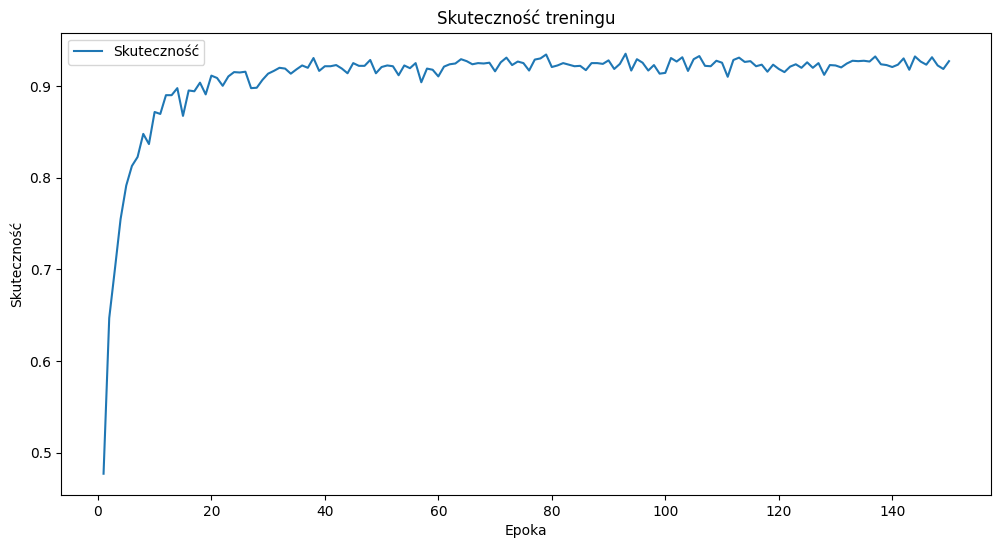

0.9351535836177475


In [17]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
 
def load_data(trial_number):
    with open(f'outputs/train_losses_trial_{trial_number}.pkl', 'rb') as f:
        train_losses = pickle.load(f)
    with open(f'outputs/val_losses_trial_{trial_number}.pkl', 'rb') as f:
        val_losses = pickle.load(f)
    with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
        accuracies = pickle.load(f)
    
    return train_losses, val_losses, accuracies
 
def plot_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, train_losses, label='Dane treningowe')
    plt.plot(epochs, val_losses, label='Dane testowe')
    plt.xlabel('Epoka')
    plt.ylabel('Strata')
    plt.title('Straty uczenia i testowania')
    plt.legend()
    plt.show()
 
def plot_accuracies(accuracies):
    epochs = range(1, len(accuracies) + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, accuracies, label='Skuteczność')
    plt.xlabel('Epoka')
    plt.ylabel('Skuteczność')
    plt.title('Skuteczność treningu')
    plt.legend()
    plt.show()
 
# Specify the trial number
trial_number = 90
 
# Load data
train_losses, val_losses, accuracies = load_data(trial_number)
 
# Plot losses
plot_losses(train_losses, val_losses)
 
# Plot accuracies
plot_accuracies(accuracies)
print(max(accuracies))

In [11]:
!pip install torchviz

  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.2
    Uninstalling sympy-1.13.2:
      Successfully uninstalled sympy-1.13.2


The best trial is 90.


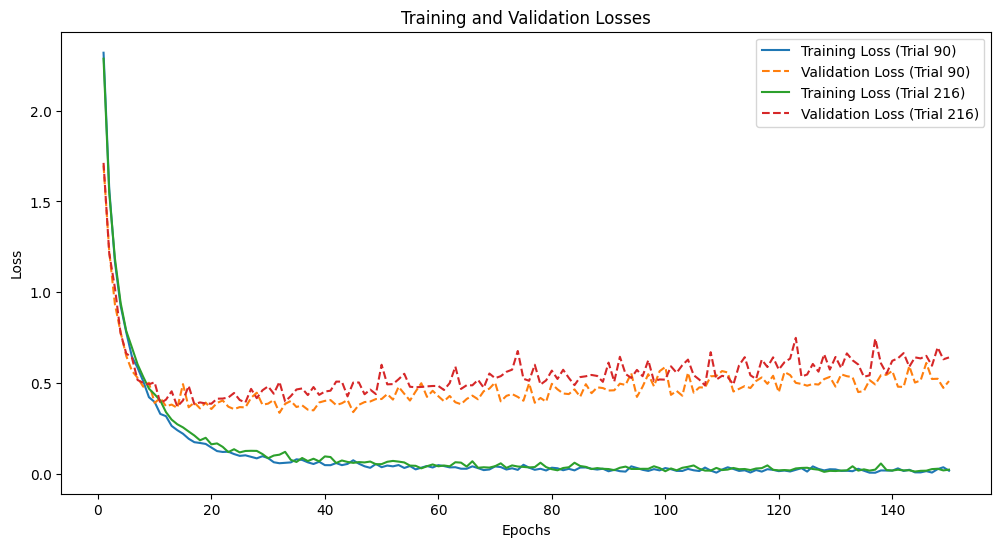

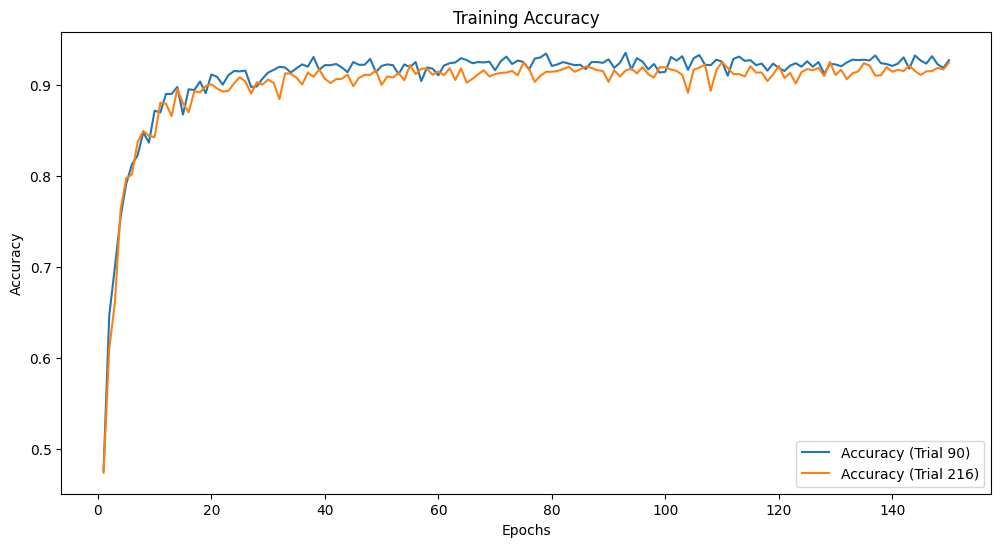

Best Trial (90):
  - Highest Accuracy: 0.9351535836177475
  - Overfitting Epoch: 9
  - Highest Accuracy Before Overfitting: 0.8476962457337884
  - Network Architecture: {'conv_layers': 3, 'filters_0': 96, 'filters_1': 64, 'filters_2': 128, 'kernel_size_0': 2, 'kernel_size_1': 3, 'kernel_size_2': 3, 'stride_0': 1, 'stride_1': 1, 'stride_2': 1, 'units': 64, 'dropout': 0.6, 'learning_rate': 0.0001}
Best Balanced Trial (216):
  - Highest Accuracy: 0.9249146757679181
  - Overfitting Epoch: 9
  - Highest Accuracy Before Overfitting: 0.8494027303754266
  - Network Architecture: {'conv_layers': 3, 'filters_0': 96, 'filters_1': 64, 'filters_2': 96, 'kernel_size_0': 2, 'kernel_size_1': 3, 'kernel_size_2': 2, 'stride_0': 1, 'stride_1': 1, 'stride_2': 1, 'units': 64, 'dropout': 0.5, 'learning_rate': 0.001}


'balanced_trial_network.png'

In [15]:
import os
import pickle
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn
from torchviz import make_dot

# Dodaj ścieżkę do Graphviz
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'

def load_data(trial_number):
    try:
        with open(f'outputs/train_losses_trial_{trial_number}.pkl', 'rb') as f:
            train_losses = pickle.load(f)
        with open(f'outputs/val_losses_trial_{trial_number}.pkl', 'rb') as f:
            val_losses = pickle.load(f)
        with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
            accuracies = pickle.load(f)
        return train_losses, val_losses, accuracies
    except FileNotFoundError:
        return None, None, None

def find_best_trial(trial_numbers):
    best_trial = None
    best_accuracy = 0
    for trial_number in trial_numbers:
        train_losses, val_losses, accuracies = load_data(trial_number)
        if train_losses is not None and val_losses is not None and accuracies is not None:
            max_accuracy = max(accuracies)
            if max_accuracy > best_accuracy:
                best_accuracy = max_accuracy
                best_trial = trial_number
    return best_trial

# Specify the trial numbers to analyze (1 to 300)
trial_numbers = list(range(1, 301))

# Find the best trial
best_trial = find_best_trial(trial_numbers)

print(f"The best trial is {best_trial}.")

def find_best_balanced_trial(trial_numbers):
    best_trial = None
    best_accuracy = 0
    for trial_number in trial_numbers:
        train_losses, val_losses, accuracies = load_data(trial_number)
        if train_losses is not None and val_losses is not None and accuracies is not None:
            for epoch in range(len(accuracies)):
                if val_losses[epoch] <= train_losses[epoch] and accuracies[epoch] > best_accuracy:
                    best_accuracy = accuracies[epoch]
                    best_trial = trial_number
    return best_trial

def plot_losses(trial_number, train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label=f'Training Loss (Trial {trial_number})')
    plt.plot(epochs, val_losses, linestyle='--', label=f'Validation Loss (Trial {trial_number})')

def plot_accuracies(trial_number, accuracies):
    epochs = range(1, len(accuracies) + 1)
    plt.plot(epochs, accuracies, label=f'Accuracy (Trial {trial_number})')

def find_overfitting_epoch(train_losses, val_losses):
    for epoch in range(len(train_losses)):
        if val_losses[epoch] > train_losses[epoch]:
            return epoch + 1
    return None

def get_trial_info(study, trial_number):
    trial = study.trials[trial_number - 1]
    return trial.params

def visualize_network(trial_params):
    class CNN(nn.Module):
        def __init__(self, conv_layers, filters, kernel_sizes, strides, dense_units, dropout_rate):
            super(CNN, self).__init__()
            self.conv_layers = nn.Sequential()
            
            in_channels = 3
            for i in range(conv_layers):
                out_channels = filters[i]
                kernel_size = kernel_sizes[i]
                stride = strides[i]
                self.conv_layers.add_module(f'conv{i+1}', nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=1))
                self.conv_layers.add_module(f'relu{i+1}', nn.ReLU())
                self.conv_layers.add_module(f'pool{i+1}', nn.AvgPool2d(kernel_size=2, stride=2))
                in_channels = out_channels
            
            self.flatten = nn.Flatten()
            
            self._to_linear = self.calculate_linear_input(conv_layers, filters, kernel_sizes, strides)
            
            self.fc1 = nn.Linear(self._to_linear, dense_units)
            self.fc2 = nn.Linear(dense_units, 20)
            
            self.dropout = nn.Dropout(dropout_rate)
        
        def calculate_linear_input(self, conv_layers, filters, kernel_sizes, strides):
            size = 64 
            for i in range(conv_layers):
                size = (size - kernel_sizes[i] + 2 * 1) // strides[i] + 1
                size = size // 2
            return filters[-1] * size * size
        
        def forward(self, x):
            x = self.conv_layers(x)
            x = self.flatten(x)
            x = self.fc1(x)
            x = self.dropout(x)
            x = self.fc2(x)
            return x

    filters = [trial_params[f'filters_{i}'] for i in range(trial_params['conv_layers'])]
    kernel_sizes = [trial_params[f'kernel_size_{i}'] for i in range(trial_params['conv_layers'])]
    strides = [trial_params[f'stride_{i}'] for i in range(trial_params['conv_layers'])]

    model = CNN(
        conv_layers=trial_params['conv_layers'],
        filters=filters,
        kernel_sizes=kernel_sizes,
        strides=strides,
        dense_units=trial_params['units'],
        dropout_rate=trial_params['dropout']
    )
    x = torch.randn(1, 3, 64, 64)  # Assuming input size 64x64 with 3 channels
    y = model(x)
    dot = make_dot(y, params=dict(model.named_parameters()))
    dot.attr(fontsize='10', margin='0.2')
    dot.node('input', 'Input\n64x64x3', shape='box')
    return dot

# Specify the trial numbers to analyze (1 to 300)
trial_numbers = list(range(1, 301))

# Find the best trial and the best balanced trial
best_trial = find_best_trial(trial_numbers)
best_balanced_trial = find_best_balanced_trial(trial_numbers)

# Load data for the best trials
train_losses_best, val_losses_best, accuracies_best = load_data(best_trial)
train_losses_balanced, val_losses_balanced, accuracies_balanced = load_data(best_balanced_trial)

# Plot losses for the best trials
plt.figure(figsize=(12, 6))
plot_losses(best_trial, train_losses_best, val_losses_best)
plot_losses(best_balanced_trial, train_losses_balanced, val_losses_balanced)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Plot accuracies for the best trials
plt.figure(figsize=(12, 6))
plot_accuracies(best_trial, accuracies_best)
plot_accuracies(best_balanced_trial, accuracies_balanced)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()

# Find overfitting epochs
overfitting_epoch_best = find_overfitting_epoch(train_losses_best, val_losses_best)
overfitting_epoch_balanced = find_overfitting_epoch(train_losses_balanced, val_losses_balanced)

# Load Optuna study
study = optuna.load_study(storage="sqlite:///127.0.0.1", study_name="train2")

# Get trial info
best_trial_info = get_trial_info(study, best_trial)
balanced_trial_info = get_trial_info(study, best_balanced_trial)

# Print trial information
print(f"Best Trial ({best_trial}):")
print(f"  - Highest Accuracy: {max(accuracies_best)}")
print(f"  - Overfitting Epoch: {overfitting_epoch_best}")
print(f"  - Highest Accuracy Before Overfitting: {max(accuracies_best[:overfitting_epoch_best])}")
print(f"  - Network Architecture: {best_trial_info}")

print(f"Best Balanced Trial ({best_balanced_trial}):")
print(f"  - Highest Accuracy: {max(accuracies_balanced)}")
print(f"  - Overfitting Epoch: {overfitting_epoch_balanced}")
print(f"  - Highest Accuracy Before Overfitting: {max(accuracies_balanced[:overfitting_epoch_balanced])}")
print(f"  - Network Architecture: {balanced_trial_info}")

# Visualize network architectures
best_trial_viz = visualize_network(best_trial_info)
balanced_trial_viz = visualize_network(balanced_trial_info)

best_trial_viz.render("best_trial_network", format="png")
balanced_trial_viz.render("balanced_trial_network", format="png")


In [42]:
!pip install onnx

   ---------------------------------------- 0.0/14.5 MB ? eta -:--:--
    --------------------------------------- 0.3/14.5 MB ? eta -:--:--
   -- ------------------------------------- 0.8/14.5 MB 2.4 MB/s eta 0:00:06
   --- ------------------------------------ 1.3/14.5 MB 2.3 MB/s eta 0:00:06
   ----- ---------------------------------- 1.8/14.5 MB 2.3 MB/s eta 0:00:06
   ----- ---------------------------------- 2.1/14.5 MB 2.3 MB/s eta 0:00:06
   ------- -------------------------------- 2.6/14.5 MB 2.3 MB/s eta 0:00:06
   -------- ------------------------------- 3.1/14.5 MB 2.3 MB/s eta 0:00:05
   ---------- ----------------------------- 3.7/14.5 MB 2.3 MB/s eta 0:00:05
   ----------- ---------------------------- 4.2/14.5 MB 2.3 MB/s eta 0:00:05
   ------------ --------------------------- 4.7/14.5 MB 2.3 MB/s eta 0:00:05
   ------------- -------------------------- 5.0/14.5 MB 2.3 MB/s eta 0:00:05
   --------------- ------------------------ 5.5/14.5 MB 2.3 MB/s eta 0:00:04
   ----------

In [73]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna
import os

# Definicja modelu CNN
class CNNModel(nn.Module):
    def __init__(self, trial_params):
        super(CNNModel, self).__init__()
        layers = []
        in_channels = 3
        for i in range(trial_params['conv_layers']):
            layers.append(nn.Conv2d(
                in_channels,
                trial_params[f'filters_{i}'],
                kernel_size=trial_params[f'kernel_size_{i}'],
                stride=trial_params[f'stride_{i}'],
                padding=trial_params.get('padding', 1)
            ))
            layers.append(nn.ReLU())
            layers.append(nn.AvgPool2d(kernel_size=2, stride=2))
            in_channels = trial_params[f'filters_{i}']
        self.conv = nn.Sequential(*layers)

        flattened_size = in_channels * (64 // (2 ** trial_params['conv_layers'])) ** 2
        self.fc1 = nn.Linear(flattened_size, trial_params['units'])
        self.dropout = nn.Dropout(trial_params['dropout'])
        self.fc2 = nn.Linear(trial_params['units'], 20)

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Wczytanie najlepszych parametrów z Optuna
study = optuna.load_study(storage="sqlite:///127.0.0.1", study_name="train2")
trial_params = study.best_trial.params

# Stworzenie modelu
model = CNNModel(trial_params)
model.eval()

# Dummy input
dummy_input = torch.randn(1, 3, 64, 64)

# Eksport do ONNX (dla Netron)
onnx_path = "model.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    opset_version=11
)
print(f"✅ Zapisano model ONNX: {onnx_path}")

# Eksport do Net2Vis (tekstowy opis)
net2vis_lines = [f"Input[64, 64, 3]"]
for i in range(trial_params['conv_layers']):
    net2vis_lines.append(f"Conv2D[{trial_params[f'filters_{i}']}, {trial_params[f'kernel_size_{i}']}, relu]")
    net2vis_lines.append("AvgPool[2]")
net2vis_lines.append("Flatten")
net2vis_lines.append(f"Dense[{trial_params['units']}, relu]")
net2vis_lines.append(f"Dropout[{trial_params['dropout']}]")
net2vis_lines.append("Dense[20, softmax]")

# Zapisanie opisu sieci do pliku Net2Vis
with open("net2vis.txt", "w") as f:
    f.write("\n".join(net2vis_lines))

print("✅ Wygenerowano opis do Net2Vis: net2vis.txt")

# Powtórzenie dla najlepszego zbalansowanego triala
# Znajdowanie najlepszego zbalansowanego triala
best_balanced_trial = find_best_balanced_trial(range(1, 301))
best_balanced_trial_info = get_trial_info(study, best_balanced_trial)

# Stworzenie modelu dla najlepszego zbalansowanego triala
balanced_model = CNNModel(best_balanced_trial_info)
balanced_model.eval()

# Dummy input
balanced_dummy_input = torch.randn(1, 3, 64, 64)

# Eksport do ONNX (dla Netron) dla najlepszego zbalansowanego modelu
balanced_onnx_path = "balanced_model.onnx"
torch.onnx.export(
    balanced_model,
    balanced_dummy_input,
    balanced_onnx_path,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    opset_version=11
)
print(f"✅ Zapisano model ONNX dla najlepszego zbalansowanego triala: {balanced_onnx_path}")

# Eksport do Net2Vis (tekstowy opis) dla najlepszego zbalansowanego triala
balanced_net2vis_lines = [f"Input[64, 64, 3]"]
for i in range(best_balanced_trial_info['conv_layers']):
    balanced_net2vis_lines.append(f"Conv2D[{best_balanced_trial_info[f'filters_{i}']}, {best_balanced_trial_info[f'kernel_size_{i}']}, relu]")
    balanced_net2vis_lines.append("AvgPool[2]")
balanced_net2vis_lines.append("Flatten")
balanced_net2vis_lines.append(f"Dense[{best_balanced_trial_info['units']}, relu]")
balanced_net2vis_lines.append(f"Dropout[{best_balanced_trial_info['dropout']}]")
balanced_net2vis_lines.append("Dense[20, softmax]")

# Zapisanie opisu sieci do pliku Net2Vis dla najlepszego zbalansowanego triala
with open("balanced_net2vis.txt", "w") as f:
    f.write("\n".join(balanced_net2vis_lines))

print("✅ Wygenerowano opis do Net2Vis dla najlepszego zbalansowanego triala: balanced_net2vis.txt")


✅ Zapisano model ONNX: model.onnx
✅ Wygenerowano opis do Net2Vis: net2vis.txt
✅ Zapisano model ONNX dla najlepszego zbalansowanego triala: balanced_model.onnx
✅ Wygenerowano opis do Net2Vis dla najlepszego zbalansowanego triala: balanced_net2vis.txt


In [44]:
pip install visualkeras

Note: you may need to restart the kernel to use updated packages.


Best model visualization saved to best_model_visualization.png
Balanced model visualization saved to balanced_model_visualization.png


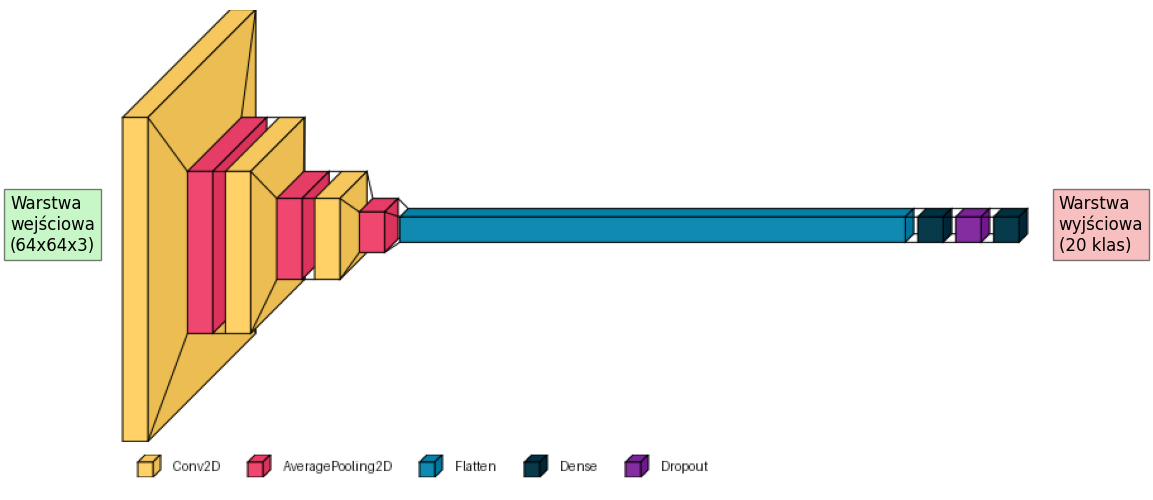

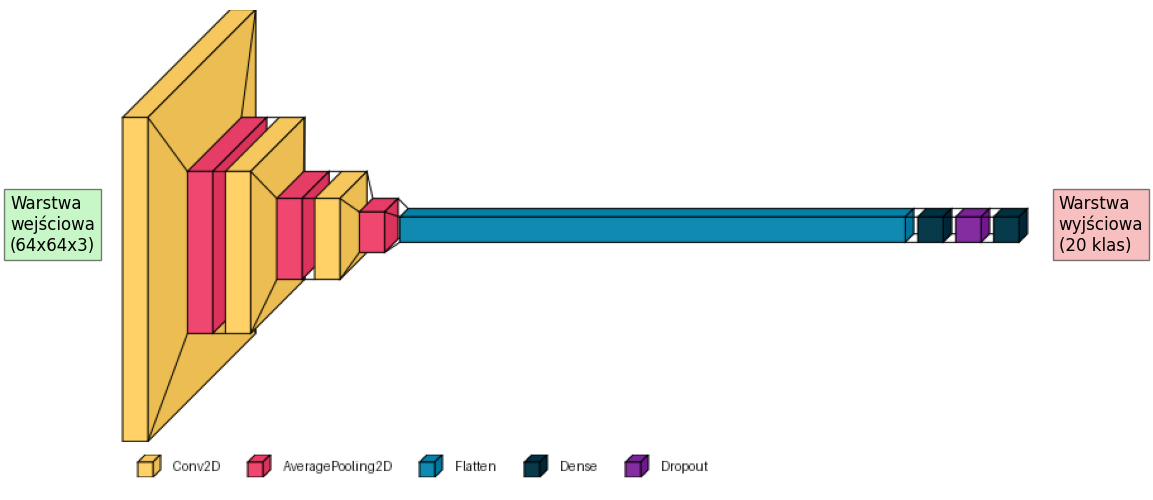

In [75]:
import numpy as np
import tensorflow as tf
import visualkeras
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Dropout, AvgPool2D
import optuna

# Funkcja do budowania modelu
def build_model(trial_params):
    model = Sequential()
    in_channels = 3
    for i in range(trial_params['conv_layers']):
        if i == 0:
            model.add(Conv2D(
                filters=trial_params[f'filters_{i}'],
                kernel_size=trial_params[f'kernel_size_{i}'],
                strides=trial_params[f'stride_{i}'],
                padding='same',
                activation='relu',
                input_shape=(64, 64, in_channels)
            ))
        else:
            model.add(Conv2D(
                filters=trial_params[f'filters_{i}'],
                kernel_size=trial_params[f'kernel_size_{i}'],
                strides=trial_params[f'stride_{i}'],
                padding='same',
                activation='relu'
            ))
        model.add(AvgPool2D(pool_size=(2, 2), strides=(2, 2)))
    model.add(Flatten())
    model.add(Dense(trial_params['units'], activation='relu'))
    model.add(Dropout(trial_params['dropout']))
    model.add(Dense(20, activation='softmax'))  # Zakładamy 20 klas
    return model

# Wczytanie najlepszych parametrów z Optuna
study = optuna.load_study(storage="sqlite:///127.0.0.1", study_name="train2")

# Parametry najlepszego trialu
best_trial_info = study.best_trial.params

# Parametry najlepszego zbalansowanego trialu
best_balanced_trial = find_best_balanced_trial(range(1, 301))
best_balanced_trial_info = get_trial_info(study, best_balanced_trial)

# Zbudowanie modelu dla najlepszego trialu
best_model = build_model(best_trial_info)

# Zbudowanie modelu dla najlepszego zbalansowanego trialu
balanced_model = build_model(best_balanced_trial_info)

# Wizualizacja modelu dla najlepszego trialu
img_best = visualkeras.layered_view(best_model, legend=True)

# Wizualizacja modelu dla najlepszego zbalansowanego trialu
img_balanced = visualkeras.layered_view(balanced_model, legend=True)

# Dodanie podpisów do wizualizacji najlepszego modelu
fig_best, ax_best = plt.subplots(figsize=(12, 8))
ax_best.imshow(img_best)
ax_best.axis('off')  # Ukrycie osi
ax_best.text(-80, 190, 'Warstwa\nwejściowa\n(64x64x3)', fontsize=12, color='black', 
             bbox=dict(facecolor='lightgreen', alpha=0.5))
ax_best.text(750, 190, 'Warstwa\nwyjściowa\n(20 klas)', fontsize=12, color='black', 
             bbox=dict(facecolor='lightcoral', alpha=0.5))

# Zapisz wizualizację najlepszego modelu do pliku PNG
output_path_best = 'best_model_visualization.png'
plt.savefig(output_path_best, format='png', bbox_inches='tight')  # Zapisz do pliku
print(f"Best model visualization saved to {output_path_best}")

# Dodanie podpisów do wizualizacji najlepszego zbalansowanego modelu
fig_balanced, ax_balanced = plt.subplots(figsize=(12, 8))
ax_balanced.imshow(img_balanced)
ax_balanced.axis('off')  # Ukrycie osi
ax_balanced.text(-80, 190, 'Warstwa\nwejściowa\n(64x64x3)', fontsize=12, color='black', 
                 bbox=dict(facecolor='lightgreen', alpha=0.5))
ax_balanced.text(750, 190, 'Warstwa\nwyjściowa\n(20 klas)', fontsize=12, color='black', 
                 bbox=dict(facecolor='lightcoral', alpha=0.5))

# Zapisz wizualizację najlepszego zbalansowanego modelu do pliku PNG
output_path_balanced = 'balanced_model_visualization.png'
plt.savefig(output_path_balanced, format='png', bbox_inches='tight')  # Zapisz do pliku
print(f"Balanced model visualization saved to {output_path_balanced}")

# Pokaż obrazy
plt.show()


The best trial is 216
The best epoch for stopping the learning process is 11


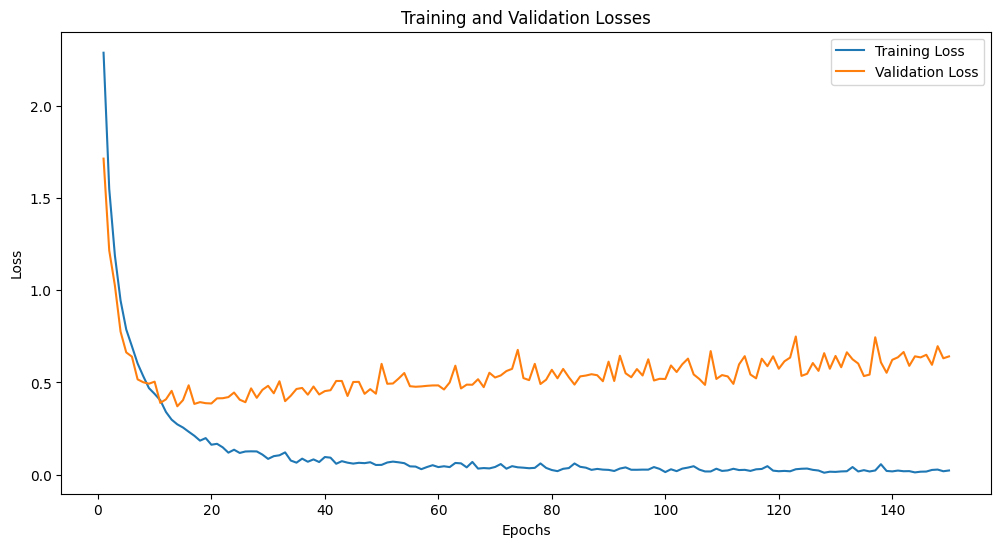

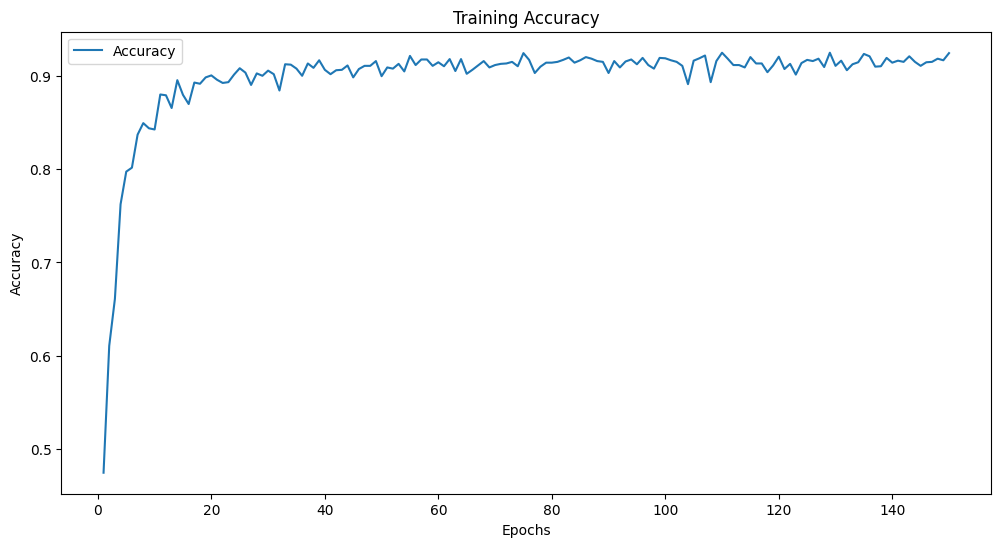

Accuracy at the best epoch (11) is 0.8801194539249146
The epoch with the highest accuracy is 110 with an accuracy of 0.9249146757679181


In [3]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

def load_data(trial_number):
    try:
        with open(f'outputs/train_losses_trial_{trial_number}.pkl', 'rb') as f:
            train_losses = pickle.load(f)
        with open(f'outputs/val_losses_trial_{trial_number}.pkl', 'rb') as f:
            val_losses = pickle.load(f)
        with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
            accuracies = pickle.load(f)
        return train_losses, val_losses, accuracies
    except FileNotFoundError:
        return None, None, None

def plot_losses(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, train_losses, label='Training Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Losses')
    plt.legend()
    plt.show()

def plot_accuracies(accuracies):
    epochs = range(1, len(accuracies) + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(epochs, accuracies, label='Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.legend()
    plt.show()

def find_best_epoch(train_losses, val_losses, accuracies, accuracy_threshold=0.90):
    best_epoch = None
    best_accuracy = 0
    for epoch in range(len(accuracies)):
        if accuracies[epoch] > best_accuracy and val_losses[epoch] < train_losses[epoch] and accuracies[epoch] >= accuracy_threshold:
            best_accuracy = accuracies[epoch]
            best_epoch = epoch + 1
    return best_epoch

def find_best_trial(trial_numbers, accuracy_threshold=0.90):
    best_trial = None
    best_accuracy = 0
    for trial_number in trial_numbers:
        train_losses, val_losses, accuracies = load_data(trial_number)
        if train_losses is not None and val_losses is not None and accuracies is not None:
            for epoch in range(len(accuracies)):
                if accuracies[epoch] > best_accuracy and val_losses[epoch] < train_losses[epoch] and accuracies[epoch] >= accuracy_threshold:
                    best_accuracy = accuracies[epoch]
                    best_trial = trial_number
                    break
    return best_trial

# Specify the trial numbers to analyze (1 to 300)
trial_numbers = list(range(1, 301))

# Find the best trial
best_trial = find_best_trial(trial_numbers, accuracy_threshold=0.80)
print(f"The best trial is {best_trial}")

if best_trial is not None:
    # Load data for the best trial
    train_losses, val_losses, accuracies = load_data(best_trial)

    # Find the best epoch for stopping the learning process
    best_epoch = find_best_epoch(train_losses, val_losses, accuracies, accuracy_threshold=0.80)
    print(f"The best epoch for stopping the learning process is {best_epoch}")

    # Plot losses for the best trial
    plot_losses(train_losses, val_losses)

    # Plot accuracies for the best trial
    plot_accuracies(accuracies)

    # Display accuracy for the best epoch
    print(f"Accuracy at the best epoch ({best_epoch}) is {accuracies[best_epoch-1]}")

    # Find and display the epoch with the highest accuracy
    highest_accuracy_epoch = accuracies.index(max(accuracies)) + 1
    print(f"The epoch with the highest accuracy is {highest_accuracy_epoch} with an accuracy of {max(accuracies)}")
else:
    print("No valid trials found.")


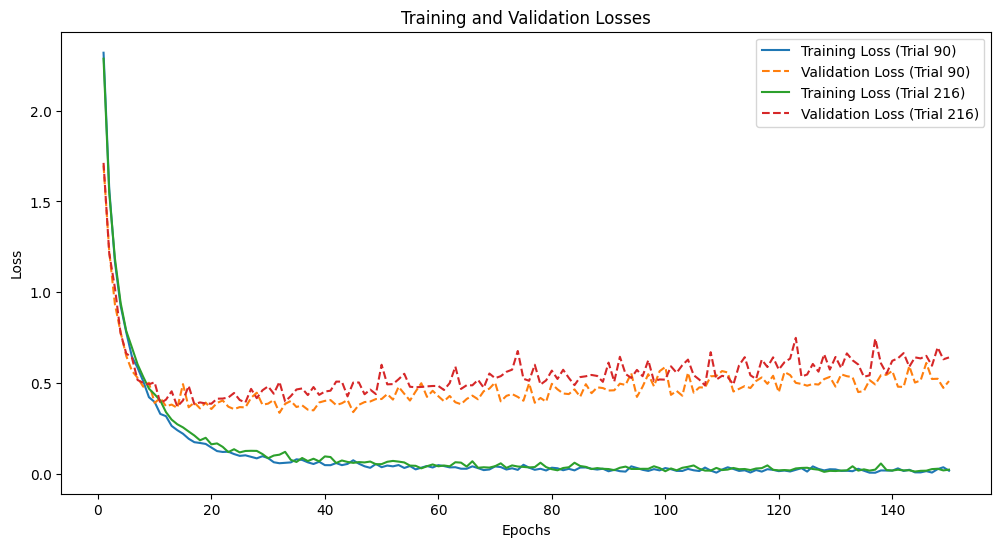

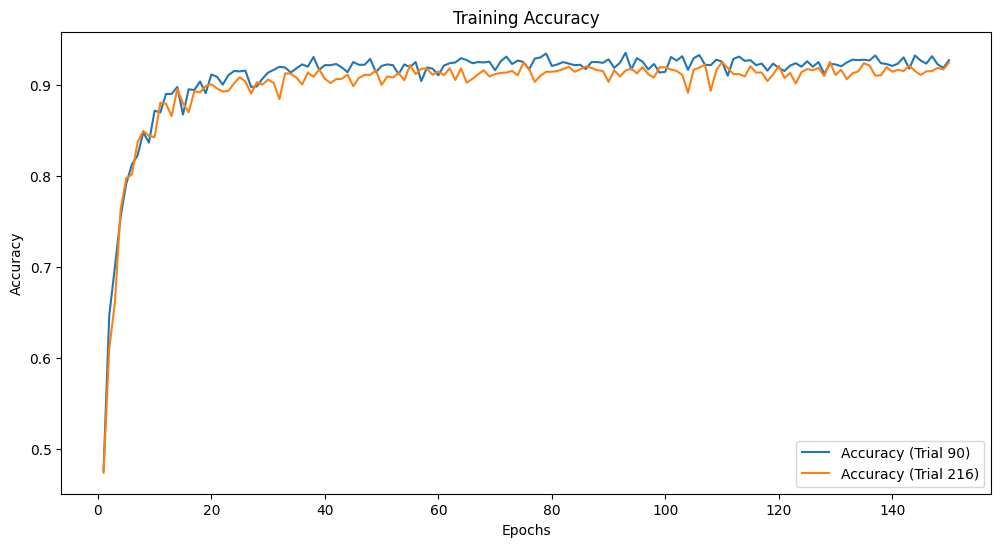

In [9]:
import pickle
import matplotlib.pyplot as plt

def load_data(trial_number):
    try:
        with open(f'outputs/train_losses_trial_{trial_number}.pkl', 'rb') as f:
            train_losses = pickle.load(f)
        with open(f'outputs/val_losses_trial_{trial_number}.pkl', 'rb') as f:
            val_losses = pickle.load(f)
        with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
            accuracies = pickle.load(f)
        return train_losses, val_losses, accuracies
    except FileNotFoundError:
        return None, None, None

def find_best_trial(trial_numbers):
    best_trial = None
    best_accuracy = 0
    for trial_number in trial_numbers:
        train_losses, val_losses, accuracies = load_data(trial_number)
        if train_losses is not None and val_losses is not None and accuracies is not None:
            for epoch in range(len(accuracies)):
                if accuracies[epoch] > best_accuracy:
                    best_accuracy = accuracies[epoch]
                    best_trial = trial_number
    return best_trial

def find_best_balanced_trial(trial_numbers):
    best_trial = None
    best_accuracy = 0
    for trial_number in trial_numbers:
        train_losses, val_losses, accuracies = load_data(trial_number)
        if train_losses is not None and val_losses is not None and accuracies is not None:
            for epoch in range(len(accuracies)):
                if accuracies[epoch] > best_accuracy and val_losses[epoch] <= train_losses[epoch]:
                    best_accuracy = accuracies[epoch]
                    best_trial = trial_number
    return best_trial

def plot_losses(trial_number, train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label=f'Training Loss (Trial {trial_number})')
    plt.plot(epochs, val_losses, linestyle='--', label=f'Validation Loss (Trial {trial_number})')

def plot_accuracies(trial_number, accuracies):
    epochs = range(1, len(accuracies) + 1)
    plt.plot(epochs, accuracies, label=f'Accuracy (Trial {trial_number})')

# Specify the trial numbers to analyze (1 to 300)
trial_numbers = list(range(1, 301))

# Find the best trial and the best balanced trial
best_trial = find_best_trial(trial_numbers)
best_balanced_trial = find_best_balanced_trial(trial_numbers)

# Load data for the best trials
train_losses_best, val_losses_best, accuracies_best = load_data(best_trial)
train_losses_balanced, val_losses_balanced, accuracies_balanced = load_data(best_balanced_trial)

# Plot losses for the best trials
plt.figure(figsize=(12, 6))
plot_losses(best_trial, train_losses_best, val_losses_best)
plot_losses(best_balanced_trial, train_losses_balanced, val_losses_balanced)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses')
plt.legend()
plt.show()

# Plot accuracies for the best trials
plt.figure(figsize=(12, 6))
plot_accuracies(best_trial, accuracies_best)
plot_accuracies(best_balanced_trial, accuracies_balanced)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.legend()
plt.show()


C:\Users\pawci\AppData\Local\Temp\ipykernel_13856\2483118762.py:12: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig1 = optuna.visualization.matplotlib.plot_optimization_history(study)


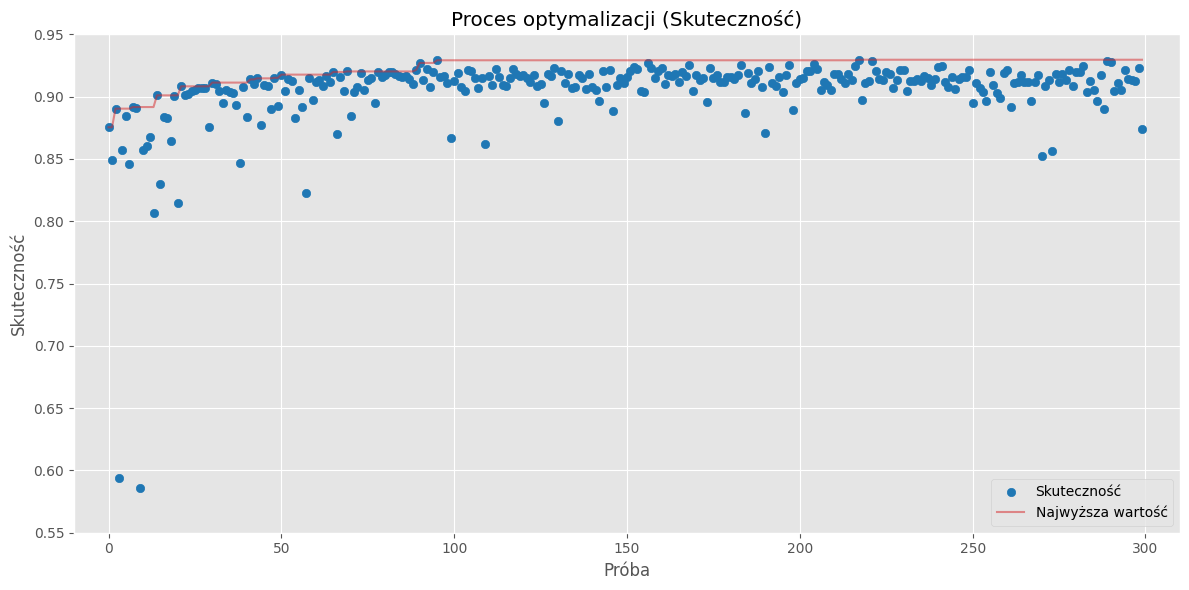

C:\Users\pawci\AppData\Local\Temp\ipykernel_13856\2483118762.py:34: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig2 = optuna.visualization.matplotlib.plot_param_importances(study)


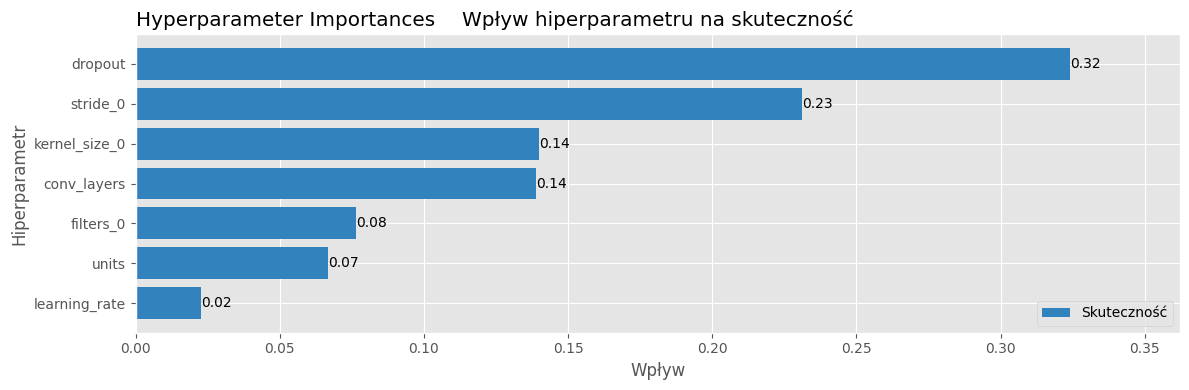

In [81]:
import optuna
import matplotlib.pyplot as plt


# Load the study from the SQLite database
study = optuna.load_study(
    storage="sqlite:///127.0.0.1",
    study_name="train2"
)

# Generate optimization history plot
fig1 = optuna.visualization.matplotlib.plot_optimization_history(study)
fig1.figure.set_size_inches(12, 6)
fig1.set_title("Proces optymalizacji (Skuteczność)")
fig1.set_ylabel("Skuteczność")
fig1.set_xlabel("Próba")
fig1.legend(["Skuteczność", "Najwyższa wartość"])
plt.ylim(0.55, 0.95)
plt.xlim(-10, 310)

best_value = float('-inf')
for trial in study.trials:
    if trial.value > best_value:
        best_value = trial.value
        # plt.scatter(trial.number, trial.value, color='red')
        # plt.annotate(f"{trial.value:.3f}", (trial.number, trial.value), textcoords="offset points", xytext=(0,10), ha='center', color='red')

plt.tight_layout()
fig1.figure.savefig("optymalizacja_skutecznosc.png", dpi=300)
plt.show()


# Generate parameter importance plot
fig2 = optuna.visualization.matplotlib.plot_param_importances(study)
fig2.figure.set_size_inches(12, 4)
fig2.set_title("Wpływ hiperparametru na skuteczność")
fig2.set_ylabel("Hiperparametr")
fig2.set_xlabel("Wpływ")
fig2.legend(["Skuteczność"])
plt.tight_layout()
fig2.figure.savefig("wplyw_hiperparametrow.png", dpi=300)
plt.show()



In [18]:
import pandas as pd
import numpy as np
import pickle
import optuna

# Load Optuna study
study = optuna.load_study(storage="sqlite:///127.0.0.1", study_name="train2")

def load_accuracy(trial_number):
    try:
        with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
            accuracies = pickle.load(f)
        return max(accuracies)
    except FileNotFoundError:
        return None

# Extract trial data
trial_data = []
for trial in study.trials:
    params = trial.params
    conv_layers = params['conv_layers']
    accuracy = load_accuracy(trial.number)
    if accuracy is not None:
        trial_info = {
            'Numer próby': trial.number,
            'Skuteczność': accuracy,
            'Liczba warstw konwolucyjnych': conv_layers,
            'Warstwa 1': f"{params['filters_0']}, {params['kernel_size_0']}, {params['stride_0']}" if conv_layers > 0 else "-",
            'Warstwa 2': f"{params['filters_1']}, {params['kernel_size_1']}, {params['stride_1']}" if conv_layers > 1 else "-",
            'Warstwa 3': f"{params['filters_2']}, {params['kernel_size_2']}, {params['stride_2']}" if conv_layers > 2 else "-",
            'Liczba jednostek gęstych': params['units'],
            'Współczynnik dropout': params['dropout'],
            'Współczynnik uczenia się': f"10^-{int(abs(np.log10(params['learning_rate']))):.0f}"
        }
        trial_data.append(trial_info)

# Create DataFrame
df = pd.DataFrame(trial_data)

# Sort DataFrame by accuracy in descending order and select top 50 trials
top_50_trials = df.sort_values(by='Skuteczność', ascending=False).head(50)

# Export the DataFrame to a CSV file with the correct format for Polish Excel
top_50_trials.to_csv('top_50_trials.csv', sep=';', index=False, encoding='utf-8-sig')

print("DataFrame has been exported to top_50_trials.csv")


DataFrame has been exported to top_50_trials.csv


In [16]:
import os
import pickle
import matplotlib.pyplot as plt
 
# Dodaj ścieżkę do Graphviz
os.environ["PATH"] += os.pathsep + 'C:/Program Files/Graphviz/bin'
 
def load_data(trial_number):
    try:
        with open(f'outputs/train_losses_trial_{trial_number}.pkl', 'rb') as f:
            train_losses = pickle.load(f)
        with open(f'outputs/val_losses_trial_{trial_number}.pkl', 'rb') as f:
            val_losses = pickle.load(f)
        with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
            accuracies = pickle.load(f)
        return train_losses, val_losses, accuracies
    except FileNotFoundError:
        return None, None, None
 
def find_best_trial(trial_numbers):
    best_trial = None
    best_accuracy = 0
    for trial_number in trial_numbers:
        train_losses, val_losses, accuracies = load_data(trial_number)
        if train_losses is not None and val_losses is not None and accuracies is not None:
            max_accuracy = max(accuracies)
            print(f"Trial {trial_number}: Max Accuracy = {max_accuracy}")
            if max_accuracy > best_accuracy:
                best_accuracy = max_accuracy
                best_trial = trial_number
    return best_trial
 
# Specify the trial numbers to analyze (1 to 300)
trial_numbers = list(range(1, 301))
 
# Find the best trial
best_trial = find_best_trial(trial_numbers)
 
print(f"The best trial is {best_trial}.")
 
def find_best_balanced_trial(trial_numbers):
    best_trial = None
    best_accuracy = 0
    for trial_number in trial_numbers:
        train_losses, val_losses, accuracies = load_data(trial_number)
        if train_losses is not None and val_losses is not None and accuracies is not None:
            for epoch in range(len(accuracies)):
                print(f"Trial {trial_number}, Epoch {epoch}: Accuracy = {accuracies[epoch]}")
                if val_losses[epoch] <= train_losses[epoch] and accuracies[epoch] > best_accuracy:
                    best_accuracy = accuracies[epoch]
                    best_trial = trial_number
    return best_trial
 
# Find the best balanced trial
best_balanced_trial = find_best_balanced_trial(trial_numbers)
 
print(f"The best balanced trial is {best_balanced_trial}.")

Trial 1: Max Accuracy = 0.8494027303754266
Trial 2: Max Accuracy = 0.893344709897611
Trial 3: Max Accuracy = 0.5938566552901023
Trial 4: Max Accuracy = 0.8758532423208191
Trial 5: Max Accuracy = 0.8852389078498294
Trial 6: Max Accuracy = 0.8459897610921502
Trial 7: Max Accuracy = 0.9014505119453925
Trial 8: Max Accuracy = 0.8963310580204779
Trial 9: Max Accuracy = 0.5878839590443686
Trial 10: Max Accuracy = 0.8707337883959044
Trial 11: Max Accuracy = 0.8848122866894198
Trial 12: Max Accuracy = 0.875
Trial 13: Max Accuracy = 0.822098976109215
Trial 14: Max Accuracy = 0.9040102389078498
Trial 15: Max Accuracy = 0.8720136518771331
Trial 16: Max Accuracy = 0.8920648464163823
Trial 17: Max Accuracy = 0.8924914675767918
Trial 18: Max Accuracy = 0.8835324232081911
Trial 19: Max Accuracy = 0.9001706484641638
Trial 20: Max Accuracy = 0.8208191126279863
Trial 21: Max Accuracy = 0.9129692832764505
Trial 22: Max Accuracy = 0.9108361774744027
Trial 23: Max Accuracy = 0.9129692832764505
Trial 24: Ma

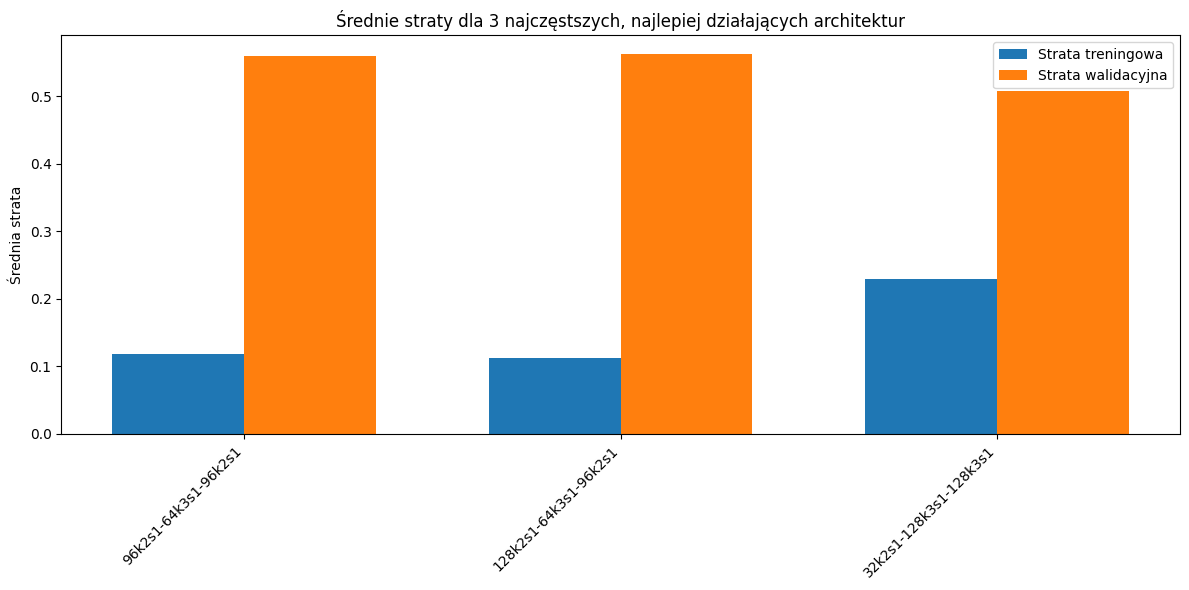

In [19]:
import optuna
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Load Optuna study
study = optuna.load_study(study_name="train2", storage="sqlite:///127.0.0.1")

def extract_arch_key(params):
    layers = params.get("conv_layers", 0)
    key_parts = []
    for i in range(layers):
        f = params.get(f"filters_{i}", "?")
        k = params.get(f"kernel_size_{i}", "?")
        s = params.get(f"stride_{i}", "?")
        key_parts.append(f"{f}k{k}s{s}")
    return "-".join(key_parts)

# 1. Zbieramy dane: architektura -> [(trial_number, accuracy)]
arch_to_trials = defaultdict(list)

for trial in study.trials:
    if trial.state != optuna.trial.TrialState.COMPLETE:
        continue

    trial_number = trial.number
    params = trial.params

    try:
        with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
            acc = pickle.load(f)
            max_acc = max(acc)
    except:
        continue

    arch_key = extract_arch_key(params)
    arch_to_trials[arch_key].append((trial_number, max_acc))

# 2. Sortujemy po liczbie wystąpień i skuteczności
sorted_archs = sorted(
    arch_to_trials.items(),
    key=lambda x: (-len(x[1]), -np.mean([acc for _, acc in x[1]]))
)

# Wybieramy top 3
top_3_archs = sorted_archs[:3]

# 3. Liczymy średnie straty
avg_train_losses = {}
avg_val_losses = {}

for arch_key, trials in top_3_archs:
    train_means, val_means = [], []

    for trial_number, _ in trials:
        try:
            with open(f'outputs/train_losses_trial_{trial_number}.pkl', 'rb') as f:
                train_losses = pickle.load(f)
            with open(f'outputs/val_losses_trial_{trial_number}.pkl', 'rb') as f:
                val_losses = pickle.load(f)
        except:
            continue

        train_means.append(np.mean(train_losses))
        val_means.append(np.mean(val_losses))

    avg_train_losses[arch_key] = np.mean(train_means)
    avg_val_losses[arch_key] = np.mean(val_means)

# 4. Wykres
labels = list(avg_train_losses.keys())
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, avg_train_losses.values(), width, label='Strata treningowa')
rects2 = ax.bar(x + width/2, avg_val_losses.values(), width, label='Strata walidacyjna')

ax.set_ylabel('Średnia strata')
ax.set_title('Średnie straty dla 3 najczęstszych, najlepiej działających architektur')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()



== Top 3 architektury ==
Architektura 1: (96, 2, 1), (64, 3, 1), (96, 2, 1), ('units', 64), ('dropout', 0.5)
Architektura 2: (128, 2, 1), (64, 3, 1), (96, 2, 1), ('units', 64), ('dropout', 0.5)
Architektura 3: (96, 2, 1), (64, 3, 1), (128, 3, 1), ('units', 64), ('dropout', 0.6)

📈 Ranking architektur (wg skuteczności przy rozważeniu przeuczenia):
Architektura 1 – Epoka ewaluacji: 18, Skuteczność: 0.8922 (Przeuczenie od epoki 18)
Architektura 2 – Epoka ewaluacji: 13, Skuteczność: 0.8822 (Przeuczenie od epoki 13)
Architektura 3 – Epoka ewaluacji: 40, Skuteczność: 0.8788 (Przeuczenie od epoki 40)

🏆 Najlepsza architektura to: Architektura 1


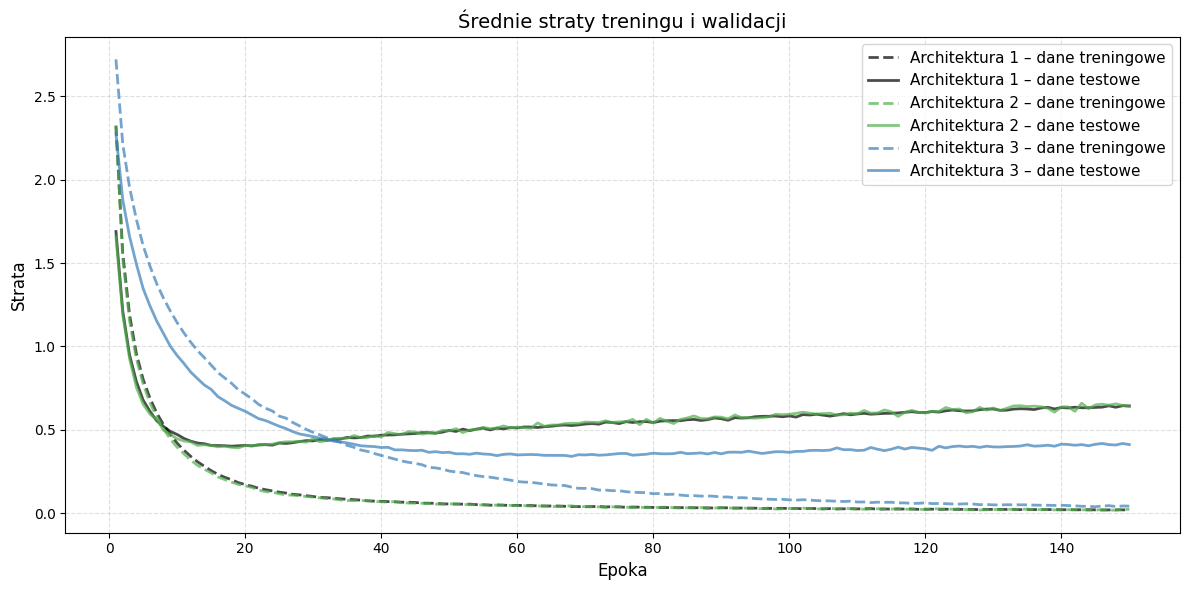

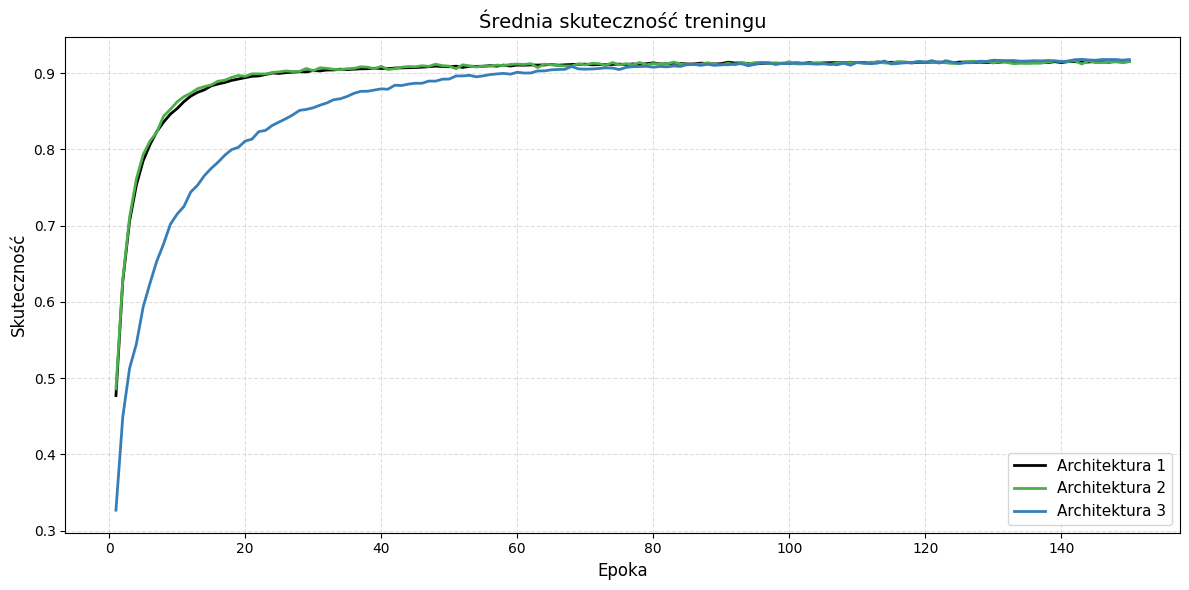

In [48]:
import optuna
import pickle
import os
from collections import defaultdict, Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ======================= PARAMS =========================
study_name = "train2"
storage_path = "sqlite:///127.0.0.1"

# =================== ARCH SIGNATURE =====================
def get_arch_signature(trial):
    conv_layers = trial.params.get("conv_layers", 0)
    arch = []
    for i in range(conv_layers):
        arch.append((
            trial.params.get(f"filters_{i}", None),
            trial.params.get(f"kernel_size_{i}", None),
            trial.params.get(f"stride_{i}", None),
        ))
    arch.append(("units", trial.params.get("units", None)))
    arch.append(("dropout", trial.params.get("dropout", None)))
    return tuple(arch)

# ================ LOAD STUDY + METRICS ==================
study = optuna.load_study(storage=storage_path, study_name=study_name)

arch_to_trials = defaultdict(list)
arch_to_accuracy = defaultdict(list)

for trial in study.trials:
    if trial.state != optuna.trial.TrialState.COMPLETE:
        continue
    try:
        arch = get_arch_signature(trial)
        trial_number = trial.number

        with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
            accuracies = pickle.load(f)
        max_acc = max(accuracies)

        arch_to_trials[arch].append(trial_number)
        arch_to_accuracy[arch].append(max_acc)
    except Exception as e:
        print(f"Skipped trial {trial.number}: {e}")

# ================ SELECT TOP 3 ARCHITEKTURY ===============
arch_freq = Counter({arch: len(trials) for arch, trials in arch_to_trials.items()})
top_archs = sorted(arch_freq.items(), key=lambda x: (-x[1], -np.mean(arch_to_accuracy[x[0]])))[:3]
top_archs = [arch for arch, _ in top_archs]

# Print architecture definitions
print("\n== Top 3 architektury ==")
for idx, arch in enumerate(top_archs, 1):
    readable_arch = []
    for item in arch:
        if isinstance(item, tuple):
            readable_arch.append(str(item))
        else:
            readable_arch.append(f"{item}")
    print(f"Architektura {idx}: {', '.join(readable_arch)}")

# ================ LOAD LOSSES & AVERAGE ===================
def load_losses(trial_number):
    with open(f'outputs/train_losses_trial_{trial_number}.pkl', 'rb') as f:
        train_losses = pickle.load(f)
    with open(f'outputs/val_losses_trial_{trial_number}.pkl', 'rb') as f:
        val_losses = pickle.load(f)
    return train_losses, val_losses

avg_curves = {}
avg_accuracies = {}

for arch in top_archs:
    all_train = []
    all_val = []
    all_acc = []
    for trial_number in arch_to_trials[arch]:
        try:
            train_losses, val_losses = load_losses(trial_number)
            with open(f'outputs/accuracies_trial_{trial_number}.pkl', 'rb') as f:
                accuracies = pickle.load(f)

            min_len = min(len(train_losses), len(val_losses), len(accuracies))
            all_train.append(train_losses[:min_len])
            all_val.append(val_losses[:min_len])
            all_acc.append(accuracies[:min_len])
        except Exception as e:
            print(f"Problem loading trial {trial_number}: {e}")
    
    train_array = np.array(all_train)
    val_array = np.array(all_val)
    acc_array = np.array(all_acc)

    avg_curves[arch] = (np.mean(train_array, axis=0), np.mean(val_array, axis=0))
    avg_accuracies[arch] = np.mean(acc_array, axis=0)

# ==================== DETEKCJA PRZEUCZENIA ====================
def detect_overfitting_epoch(train_loss, val_loss):
    """
    Znajduje pierwszą epokę, gdzie val_loss rośnie, a train_loss spada.
    """
    for i in range(1, len(train_loss)):
        if val_loss[i] > val_loss[i - 1] and train_loss[i] < train_loss[i - 1]:
            return i
    return None  # brak klasycznego przeuczenia

results = []

for idx, arch in enumerate(top_archs):
    train_loss, val_loss = avg_curves[arch]
    accuracy = avg_accuracies[arch]

    overfit_epoch = detect_overfitting_epoch(train_loss, val_loss)

    if overfit_epoch is not None:
        eval_epoch = overfit_epoch
        score = accuracy[eval_epoch]
        reason = f"Przeuczenie od epoki {overfit_epoch}"
    else:
        eval_epoch = int(np.argmax(accuracy))
        score = accuracy[eval_epoch]
        reason = "Brak przeuczenia – użyto max accuracy"

    results.append({
        "arch_idx": idx + 1,
        "eval_epoch": eval_epoch,
        "accuracy_at_eval": score,
        "reason": reason
    })

sorted_results = sorted(results, key=lambda x: x["accuracy_at_eval"], reverse=True)

# Print
print("\n📈 Ranking architektur (wg skuteczności przy rozważeniu przeuczenia):")
for res in sorted_results:
    print(f"Architektura {res['arch_idx']} – Epoka ewaluacji: {res['eval_epoch']}, "
          f"Skuteczność: {res['accuracy_at_eval']:.4f} ({res['reason']})")

print(f"\n🏆 Najlepsza architektura to: Architektura {sorted_results[0]['arch_idx']}")

# ==================== PLOTTING STRATY ============================
custom_colors = ['#000000', '#4daf4a', '#377eb8']  # czarny, zielony, niebieski

# Wykres 1: Straty
plt.figure(figsize=(12, 6))
for idx, (arch, (mean_train, mean_val)) in enumerate(avg_curves.items()):
    epochs = range(1, len(mean_train) + 1)
    color = custom_colors[idx % len(custom_colors)]
    
    plt.plot(epochs, mean_train, label=f'Architektura {idx+1} – dane treningowe', linestyle='--', color=color, linewidth=2, alpha=.7)
    plt.plot(epochs, mean_val, label=f'Architektura {idx+1} – dane testowe', linestyle='-', color=color, linewidth=2, alpha=.7)

plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Strata', fontsize=12)
plt.title('Średnie straty treningu i walidacji', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("straty_architektury.png")
plt.show()

# ==================== PLOTTING ACCURACY ============================
# Wykres 2: Accuracy
plt.figure(figsize=(12, 6))
for idx, (arch, mean_acc) in enumerate(avg_accuracies.items()):
    epochs = range(1, len(mean_acc) + 1)
    color = custom_colors[idx % len(custom_colors)]
    
    plt.plot(epochs, mean_acc, label=f'Architektura {idx+1}', linestyle='-', color=color, linewidth=2)

plt.xlabel('Epoka', fontsize=12)
plt.ylabel('Skuteczność', fontsize=12)
plt.title('Średnia skuteczność treningu', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("accuracy_architektury.png")
plt.show()


# MODEL MANUAL EVAL

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os

# Definicja modelu z ręcznie podanymi parametrami
class ManualCNN(nn.Module):
    def __init__(self):
        super(ManualCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=2, stride=1, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(96, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 96, kernel_size=2, stride=1, padding=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(96 * 8 * 8, 64)  # Zakładamy wejście 64x64
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(64, 20)

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Stworzenie instancji modelu
model = ManualCNN()
model.eval()

# Dummy input (np. dla obrazu 64x64 RGB)
dummy_input = torch.randn(1, 3, 64, 64)

# Eksport do ONNX
onnx_path = "manual_model.onnx"
torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}},
    training=torch.onnx.TrainingMode.TRAINING, # Dodanie trybu training
    opset_version=11
)

print(f"✅ Zapisano model ONNX: {onnx_path}")

C:\Users\pawci\miniconda3\envs\satelliteCNN\Lib\site-packages\torch\onnx\utils.py:491: FutureWarning: Setting `training` to something other than default is deprecated. The option will be removed in a future release. Please set the training mode before exporting the model.
  warnings.warn(
C:\Users\pawci\miniconda3\envs\satelliteCNN\Lib\site-packages\torch\onnx\utils.py:86: UserWarning: You are exporting the model in training mode with onnx opset version 11. Opset versions lower than opset 12 will not be able to export nodes such as Dropout and BatchNorm correctly.
  warnings.warn(
C:\Users\pawci\miniconda3\envs\satelliteCNN\Lib\site-packages\torch\onnx\utils.py:760: UserWarning: It is recommended that constant folding be turned off ('do_constant_folding=False') when exporting the model in training-amenable mode, i.e. with 'training=TrainingMode.TRAIN' or 'training=TrainingMode.PRESERVE' (when model is in training mode). Otherwise, some learnable model parameters may not translate corre

✅ Zapisano model ONNX: manual_model.onnx


C:\Users\pawci\miniconda3\envs\satelliteCNN\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\pawci\miniconda3\envs\satelliteCNN\Lib\site-packages\visualkeras\layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


✅ Zapisano wizualizację modelu do pliku: manual_model_visualization.png


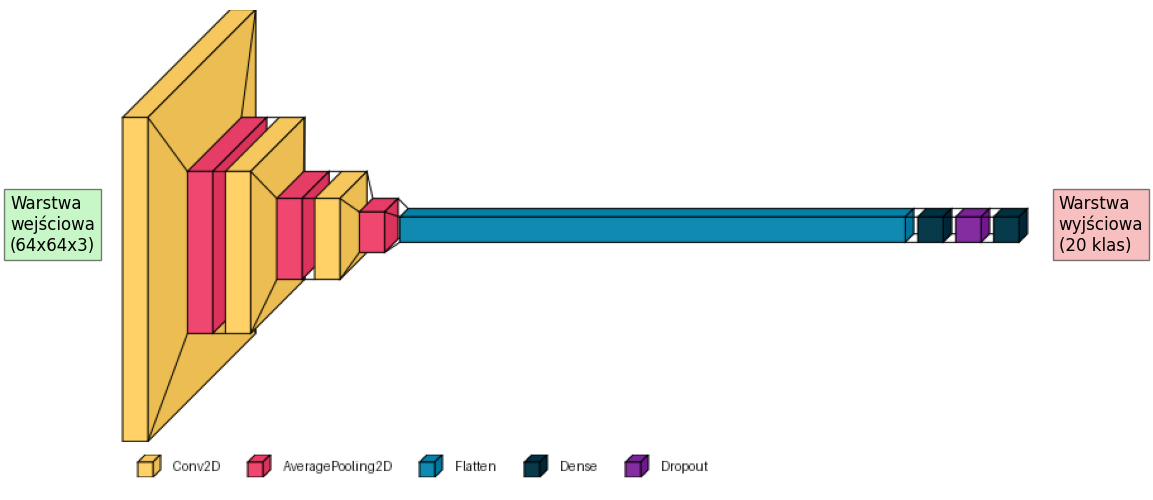

In [66]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AvgPool2D, Flatten, Dense, Dropout
import visualkeras
import matplotlib.pyplot as plt

# Zdefiniuj model dokładnie jak Twój manualny PyTorch model, ale w Kerasie
model = Sequential()
model.add(Conv2D(96, kernel_size=2, strides=1, padding='same', activation='relu', input_shape=(64, 64, 3)))
model.add(AvgPool2D(pool_size=2, strides=2))
model.add(Conv2D(64, kernel_size=3, strides=1, padding='same', activation='relu'))
model.add(AvgPool2D(pool_size=2, strides=2))
model.add(Conv2D(96, kernel_size=2, strides=1, padding='same', activation='relu'))
model.add(AvgPool2D(pool_size=2, strides=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(20, activation='softmax'))

# Generuj wizualizację
img = visualkeras.layered_view(model, legend=True)

# Tworzenie obrazu z podpisami
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img)
ax.axis('off')  # Ukrycie osi
ax.text(-80, 190, 'Warstwa\nwejściowa\n(64x64x3)', fontsize=12, color='black', 
        bbox=dict(facecolor='lightgreen', alpha=0.5))
ax.text(750, 190, 'Warstwa\nwyjściowa\n(20 klas)', fontsize=12, color='black', 
        bbox=dict(facecolor='lightcoral', alpha=0.5))

# Zapis do pliku
output_path = 'manual_model_visualization.png'
plt.savefig(output_path, format='png', bbox_inches='tight')
print(f"✅ Zapisano wizualizację modelu do pliku: {output_path}")

# Wyświetl obraz
plt.show()


In [28]:
np.set_printoptions(precision=1, suppress=True)
print("[")
for row in mean_conf_matrix:
    print("    [" + ", ".join(f"{val:.1f}" for val in row) + "],")
print("]")

[
    [142.0, 0.6, 0.2, 5.1, 0.3, 0.0, 0.0, 3.7, 0.0, 0.0, 18.3, 0.0, 3.1, 0.6, 0.0, 0.9, 0.0, 0.0, 0.1, 0.1],
    [0.0, 97.0, 0.0, 0.0, 0.0, 0.8, 0.0, 0.0, 1.7, 0.0, 0.1, 0.2, 0.0, 0.2, 0.6, 1.2, 0.0, 0.0, 0.2, 0.0],
    [0.1, 0.0, 36.7, 0.1, 0.0, 5.0, 0.0, 1.7, 0.1, 0.0, 0.0, 0.7, 0.0, 0.4, 0.6, 0.0, 0.3, 1.6, 0.4, 3.3],
    [2.5, 0.1, 0.1, 43.5, 0.0, 0.1, 0.4, 1.7, 0.8, 0.1, 0.0, 0.0, 5.5, 0.0, 0.1, 0.4, 0.8, 0.1, 0.1, 0.7],
    [0.0, 0.0, 0.0, 0.0, 145.7, 0.2, 1.7, 0.1, 0.0, 0.1, 0.0, 0.2, 0.0, 0.1, 0.0, 2.9, 0.0, 0.0, 0.0, 0.0],
    [0.4, 0.3, 1.3, 0.0, 1.3, 182.7, 0.3, 0.3, 0.3, 0.0, 0.0, 2.5, 0.0, 2.9, 2.0, 0.3, 0.0, 0.9, 7.3, 1.2],
    [0.1, 0.0, 0.0, 0.4, 1.3, 0.7, 47.8, 0.3, 0.0, 0.0, 0.0, 0.6, 0.1, 0.2, 0.0, 3.0, 0.0, 0.0, 0.5, 0.0],
    [0.6, 0.0, 1.8, 2.9, 0.0, 0.0, 0.0, 237.4, 0.1, 0.0, 0.0, 0.1, 0.2, 0.3, 0.2, 0.0, 1.3, 0.5, 0.0, 0.6],
    [0.1, 1.2, 1.2, 0.4, 0.0, 0.1, 0.7, 0.0, 119.7, 0.0, 0.0, 0.1, 0.2, 0.6, 0.3, 0.0, 0.0, 1.0, 0.4, 0.0],
    [0.0, 2.2, 0.0, 0.0, 0.0,